# 1. Load data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
from sklearn import set_config
set_config(display='text')

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


In [2]:
df = pd.read_csv("carclaims.csv")

In [3]:
df.shape

(15420, 33)

In [4]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


# 2. Clean columns names (cleaning)

In [5]:
df.columns = df.columns.str.lower().str.replace('[^a-z0-9]', '_', regex=True)
print(df.columns.tolist())

['month', 'weekofmonth', 'dayofweek', 'make', 'accidentarea', 'dayofweekclaimed', 'monthclaimed', 'weekofmonthclaimed', 'sex', 'maritalstatus', 'age', 'fault', 'policytype', 'vehiclecategory', 'vehicleprice', 'policynumber', 'repnumber', 'deductible', 'driverrating', 'days_policy_accident', 'days_policy_claim', 'pastnumberofclaims', 'ageofvehicle', 'ageofpolicyholder', 'policereportfiled', 'witnesspresent', 'agenttype', 'numberofsuppliments', 'addresschange_claim', 'numberofcars', 'year', 'basepolicy', 'fraudfound']


# 3. Drop Leakage and Useless Columns

In [6]:
drop_cols = [
    'policynumber',
    'repnumber',
    'daysofpolicyclaimed',
    'dayofweekclaimed',
    'monthclaimed',
    'weekofmonthclaimed',
    'days_policy_claim',
]

drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print("Remaining shape:", df.shape)

Remaining shape: (15420, 27)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   month                 15420 non-null  str  
 1   weekofmonth           15420 non-null  int64
 2   dayofweek             15420 non-null  str  
 3   make                  15420 non-null  str  
 4   accidentarea          15420 non-null  str  
 5   sex                   15420 non-null  str  
 6   maritalstatus         15420 non-null  str  
 7   age                   15420 non-null  int64
 8   fault                 15420 non-null  str  
 9   policytype            15420 non-null  str  
 10  vehiclecategory       15420 non-null  str  
 11  vehicleprice          15420 non-null  str  
 12  deductible            15420 non-null  int64
 13  driverrating          15420 non-null  int64
 14  days_policy_accident  15420 non-null  str  
 15  pastnumberofclaims    15420 non-null  str  
 16  ageofvehicle   

# Split Data

In [8]:
y = df["fraudfound"] #target fraudfound column
x  = df.drop(columns=["fraudfound"])

X_train, X_other, y_train, y_other = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=510) #70 - 30 split

X_val, X_test, y_val, y_test = train_test_split(
    X_other, y_other, test_size=0.5, stratify=y_other, random_state=510) #15 - 15 split for validation and test

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

#Encode target to binary (0/1)
y_train = y_train.map({"No": 0, "Yes": 1})
y_val = y_val.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

# Quick check
print("y_train unique values:", y_train.unique())
print(y_train.value_counts())

Training: (10794, 26) (10794,)
Validation: (2313, 26) (2313,)
Test: (2313, 26) (2313,)
y_train unique values: [0 1]
fraudfound
0    10148
1      646
Name: count, dtype: int64


In [9]:
# Check fraud distribution in train, validation, and test sets
def fraud_distribution(y, name):
    counts = y.value_counts()
    percentages = y.value_counts(normalize=True) * 100
    print(f"\n{name} Set")
    print("-" * 30)

    distribution = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)})
    print(distribution)

fraud_distribution(y_train, "Training")
fraud_distribution(y_val, "Validation")
fraud_distribution(y_test, "Test")


Training Set
------------------------------
            Count  Percentage
fraudfound                   
0           10148       94.02
1             646        5.98

Validation Set
------------------------------
            Count  Percentage
fraudfound                   
0            2174       93.99
1             139        6.01

Test Set
------------------------------
            Count  Percentage
fraudfound                   
0            2175       94.03
1             138        5.97


# 5. Handle Missing Values & Fix Errors


In [10]:
df[df["age"] == 0]["fraudfound"].value_counts()

fraudfound
No     289
Yes     31
Name: count, dtype: int64

In [11]:
(df["age"] == 0).sum()

np.int64(320)

In [12]:
# Create placeholder flag before replacing values
for dataset in [X_train, X_val, X_test]:
    dataset["is_age_placeholder"] = (dataset["age"] == 0).astype(int)

# Replace invalid age = 0 with NaN
for dataset in [X_train, X_val, X_test]:
    dataset["age"] = dataset["age"].replace(0, np.nan)

# Compute medians from TRAIN ONLY
group_medians = (
    X_train.groupby(["maritalstatus", "vehicleprice"])["age"].median())

global_median = X_train["age"].median()

In [13]:
# Function to impute age using Median from Train set
def fill_age(dataset):
    keys = pd.MultiIndex.from_frame(
        dataset[["maritalstatus", "vehicleprice"]])

    dataset["age"] = dataset["age"].fillna(
        pd.Series(keys.map(group_medians), index=dataset.index))

    dataset["age"] = dataset["age"].fillna(global_median)
    return dataset

# Apply to all datasets
X_train = fill_age(X_train)
X_val = fill_age(X_val)
X_test = fill_age(X_test)

In [14]:
# Final check
print("Train zeros:", (X_train["age"] == 0).sum())
print("Validation zeros:", (X_val["age"] == 0).sum())
print("Test zeros:", (X_test["age"] == 0).sum())

print("Missing values:")
print(X_train["age"].isna().sum())
print(X_val["age"].isna().sum())
print(X_test["age"].isna().sum())

Train zeros: 0
Validation zeros: 0
Test zeros: 0
Missing values:
0
0
0


# 6. Feature engineering (new columns)

In [15]:
datasets = [X_train, X_val, X_test]
for df_ in datasets:

    # High claim history
    df_["high_claim_history"] = df_["pastnumberofclaims"].isin(["2 to 4", "more than 4"]).astype(int)
    # Weekend accident
    df_["weekend_accident"] = df_["dayofweek"].isin(["Saturday", "Sunday"]).astype(int)
    # Old vehicle
    df_["old_vehicle"] = df_["ageofvehicle"].isin(["7 years", "more than 7"]).astype(int)

# 7. Encode categoricals

### Ordinal Encoding

In [16]:
ordinal_cols = [
    "vehicleprice",
    "days_policy_accident",
    "pastnumberofclaims",
    "ageofvehicle",
    "ageofpolicyholder",
    "numberofsuppliments",
    "addresschange_claim",
    "numberofcars"
]


In [17]:
ord_enc = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[ordinal_cols] = ord_enc.fit_transform(X_train[ordinal_cols])
X_val[ordinal_cols] = ord_enc.transform(X_val[ordinal_cols])
X_test[ordinal_cols] = ord_enc.transform(X_test[ordinal_cols])

### Label Encoding

In [18]:
label_cols = [
    "accidentarea",
    "sex",
    "fault",
    "policereportfiled",
    "witnesspresent",
    "agenttype",
    "basepolicy"
]

#Scale numerical variables


In [19]:
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

    label_encoders[col] = le

### One-hot (nominal)


In [20]:
onehot_cols = [
    "make",
    "policytype",
    "vehiclecategory",
    "month",
    "dayofweek",
    "maritalstatus"
]

In [21]:
# Train
X_train = pd.get_dummies(X_train, columns=onehot_cols, drop_first=True)

# Val/Test
X_val = pd.get_dummies(X_val, columns=onehot_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=onehot_cols, drop_first=True)

# Align columns (CRUCIAL)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 8. Scale numerical variables

In [22]:
num_cols = ["weekofmonth", "age", "deductible", "driverrating", "year"]
scaler = StandardScaler()

# Fit on TRAIN only
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Apply to val and test
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,weekofmonth,accidentarea,sex,age,fault,vehicleprice,deductible,driverrating,days_policy_accident,pastnumberofclaims,...,month_Sep,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,maritalstatus_Married,maritalstatus_Single,maritalstatus_Widow
7867,1.727909,1,1,-1.029873,1,1.0,-0.172803,-1.337382,3.0,1.0,...,False,False,False,False,True,False,False,True,False,False
13654,0.167609,1,1,-1.029873,0,4.0,-0.172803,0.453093,3.0,0.0,...,False,False,False,False,True,False,False,True,False,False
8819,-1.392692,1,1,0.687445,0,1.0,-0.172803,1.348330,3.0,1.0,...,False,True,False,False,False,False,False,True,False,False
723,0.947759,1,1,-0.539210,0,0.0,-0.172803,0.453093,3.0,0.0,...,False,False,False,False,False,False,True,False,True,False
14853,0.947759,1,1,0.932776,0,0.0,-0.172803,1.348330,3.0,1.0,...,False,False,True,False,False,False,False,True,False,False


### Dummy Classifier as Baseline Model

In [23]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

#Majority-class baseline
dummy = DummyClassifier(strategy='most_frequent')

# Train
dummy.fit(X_train, y_train)

# Predict
y_dummy_pred = dummy.predict(X_val)

# Evaluation
print("Dummy Classifier Accuracy:",
      accuracy_score(y_val, y_dummy_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_dummy_pred, zero_division=0))

Dummy Classifier Accuracy: 0.9399048854301773

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2174
           1       0.00      0.00      0.00       139

    accuracy                           0.94      2313
   macro avg       0.47      0.50      0.48      2313
weighted avg       0.88      0.94      0.91      2313



# Resampling


### No Resampling

In [24]:
def no_resampling(X_train, y_train):
    """
    Return original training data without modification
    """
    return X_train, y_train

### Random Oversampling

In [25]:
def random_oversampling(X_train, y_train):
    """
    Apply random oversampling to balance classes
    """
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_train, y_train)
    
    return X_resampled, y_resampled

### SMOTE

In [26]:
def smote_resampling(X_train, y_train):
    """
    Apply SMOTE to generate synthetic minority samples
    """
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    
    return X_resampled, y_resampled

# Logistic Regression

## Fitting the models

In [27]:
# LR 1: No resampling
X_train_lr1, y_train_lr1 = no_resampling(X_train, y_train)

lr1 = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr1.fit(X_train_lr1, y_train_lr1)

y_val_proba_lr1 = lr1.predict_proba(X_val)[:, 1]
y_val_pred_lr1  = (y_val_proba_lr1 >= 0.5).astype(int)


# LR 2: Random oversampling
X_train_lr2, y_train_lr2 = random_oversampling(X_train, y_train)

lr2 = LogisticRegression(random_state=42, max_iter=1000)
lr2.fit(X_train_lr2, y_train_lr2)

y_val_proba_lr2 = lr2.predict_proba(X_val)[:, 1]
y_val_pred_lr2  = (y_val_proba_lr2 >= 0.5).astype(int)

# LR 3: SMOTE
X_train_lr3, y_train_lr3 = smote_resampling(X_train, y_train)

lr3 = LogisticRegression(random_state=42, max_iter=1000)
lr3.fit(X_train_lr3, y_train_lr3)

y_val_proba_lr3 = lr3.predict_proba(X_val)[:, 1]
y_val_pred_lr3  = (y_val_proba_lr3 >= 0.5).astype(int)


## Evaluation Metrics + Confusion Matrices


=== Logistic Regression — Validation Results ===
               Model  PR-AUC  ROC-AUC  Precision  Recall     F1
LR-1 (no resampling)  0.1783   0.7916     0.1319  0.8417 0.2281
 LR-2 (oversampling)  0.1781   0.7909     0.1284  0.8129 0.2218
        LR-3 (SMOTE)  0.1492   0.7227     0.1967  0.0863 0.1200


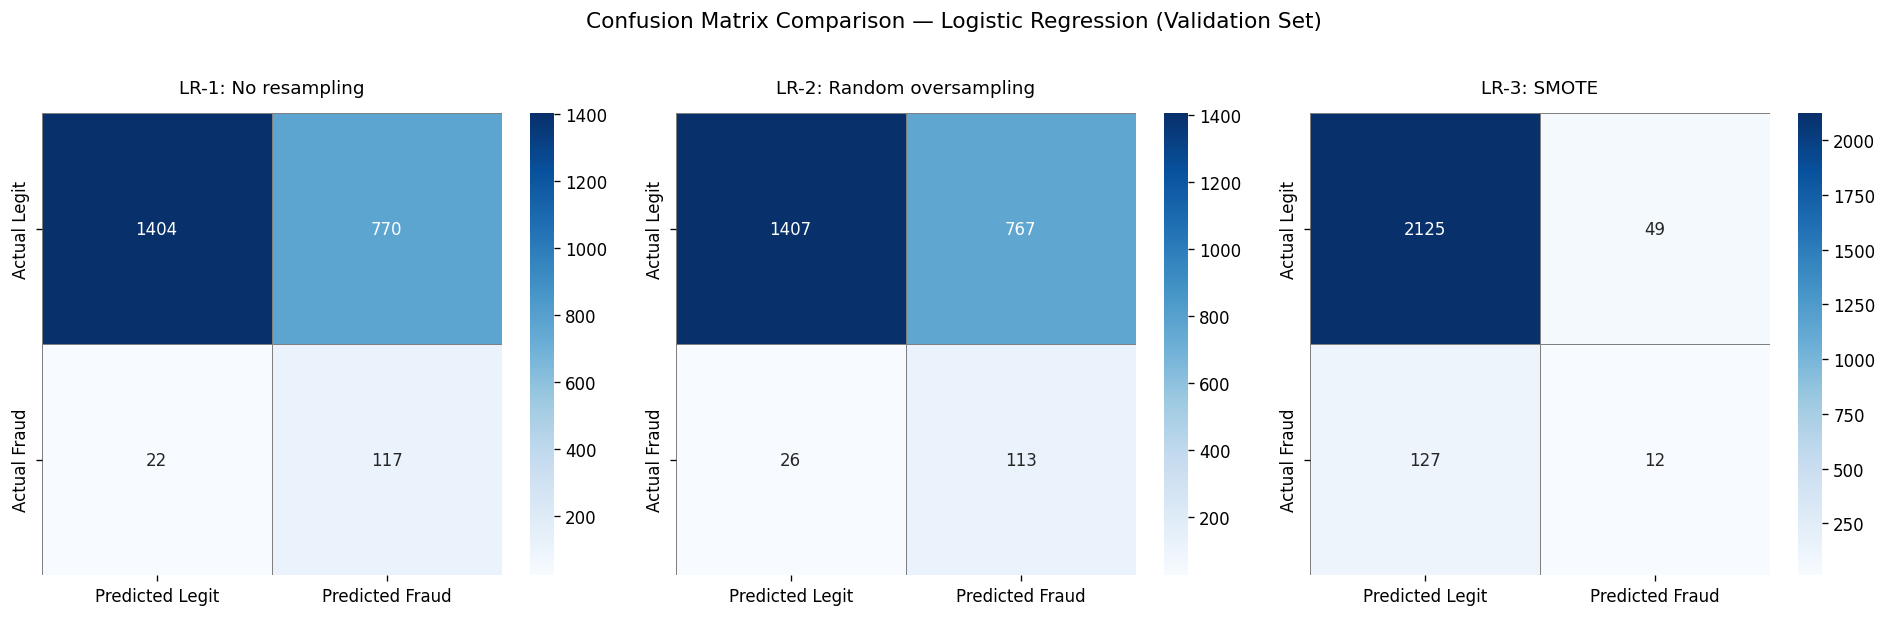

In [28]:
lr1_val_pr_auc   = average_precision_score(y_val, y_val_proba_lr1)
lr1_val_roc_auc  = roc_auc_score(y_val, y_val_proba_lr1)
lr1_val_precision = precision_score(y_val, y_val_pred_lr1, zero_division=0)
lr1_val_recall   = recall_score(y_val, y_val_pred_lr1, zero_division=0)
lr1_val_f1       = f1_score(y_val, y_val_pred_lr1, zero_division=0)
lr1_val_cm       = confusion_matrix(y_val, y_val_pred_lr1)

lr2_val_pr_auc   = average_precision_score(y_val, y_val_proba_lr2)
lr2_val_roc_auc  = roc_auc_score(y_val, y_val_proba_lr2)
lr2_val_precision = precision_score(y_val, y_val_pred_lr2, zero_division=0)
lr2_val_recall   = recall_score(y_val, y_val_pred_lr2, zero_division=0)
lr2_val_f1       = f1_score(y_val, y_val_pred_lr2, zero_division=0)
lr2_val_cm       = confusion_matrix(y_val, y_val_pred_lr2)

lr3_val_pr_auc   = average_precision_score(y_val, y_val_proba_lr3)
lr3_val_roc_auc  = roc_auc_score(y_val, y_val_proba_lr3)
lr3_val_precision = precision_score(y_val, y_val_pred_lr3, zero_division=0)
lr3_val_recall   = recall_score(y_val, y_val_pred_lr3, zero_division=0)
lr3_val_f1       = f1_score(y_val, y_val_pred_lr3, zero_division=0)
lr3_val_cm       = confusion_matrix(y_val, y_val_pred_lr3)

# Summary table
results_lr = pd.DataFrame({
    'Model': ['LR-1 (no resampling)', 'LR-2 (oversampling)', 'LR-3 (SMOTE)'],
    'PR-AUC':    [lr1_val_pr_auc,    lr2_val_pr_auc,    lr3_val_pr_auc],
    'ROC-AUC':   [lr1_val_roc_auc,   lr2_val_roc_auc,   lr3_val_roc_auc],
    'Precision': [lr1_val_precision,  lr2_val_precision,  lr3_val_precision],
    'Recall':    [lr1_val_recall,     lr2_val_recall,     lr3_val_recall],
    'F1':        [lr1_val_f1,         lr2_val_f1,         lr3_val_f1],
}).round(4)

print("\n=== Logistic Regression — Validation Results ===")
print(results_lr.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_lr = [
    (lr1_val_cm, 'LR-1: No resampling'),
    (lr2_val_cm, 'LR-2: Random oversampling'),
    (lr3_val_cm, 'LR-3: SMOTE'),
]

for ax, (cm, title) in zip(axes, models_lr):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Logistic Regression (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Precision-Recall Curves for the models

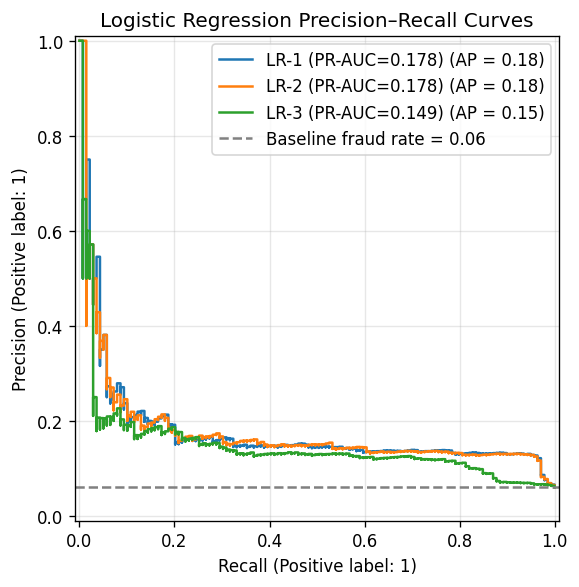

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))

# LR-1
PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_lr1,
    name=f"LR-1 (PR-AUC={lr1_val_pr_auc:.3f})",
    ax=ax
)

# LR-2
PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_lr2,
    name=f"LR-2 (PR-AUC={lr2_val_pr_auc:.3f})",
    ax=ax
)

# LR-3
PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_lr3,
    name=f"LR-3 (PR-AUC={lr3_val_pr_auc:.3f})",
    ax=ax
)

# Baseline fraud rate
fraud_rate = y_val.mean()

ax.axhline(
    fraud_rate,
    color="gray",
    linestyle="--",
    label=f"Baseline fraud rate = {fraud_rate:.2f}"
)

# Formatting
ax.set_title("Logistic Regression Precision–Recall Curves")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Leakage check

In [30]:
train_idx = set(X_train.index)
val_idx   = set(X_val.index)
test_idx  = set(X_test.index)

print("\nLeakage check")
print(f"Train/Val overlap:  {len(train_idx & val_idx)} samples")
print(f"Train/Test overlap: {len(train_idx & test_idx)} samples")
print(f"Val/Test overlap:   {len(val_idx & test_idx)} samples")
print(f"Total accounted for: {len(train_idx | val_idx | test_idx)} (should be 15420)")


Leakage check
Train/Val overlap:  0 samples
Train/Test overlap: 0 samples
Val/Test overlap:   0 samples
Total accounted for: 15420 (should be 15420)


# Hyperparameter tuning for LR-1

In [31]:
# Base LR model
lr_base = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

# Grid for LR-1
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]   # supports both l1 and l2
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    estimator=lr_base,
    param_grid=lr_param_grid,
    scoring="average_precision",   # PR-AUC
    cv=cv,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best CV PR-AUC:", round(lr_grid.best_score_, 4))
print("Best parameters:", lr_grid.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb2xkZXJzLzk5L3c4c19xOTNkNTM5M2xxMnhoZjNmZjYwdzAwMDBnbi9UL2pvYmxpYl9tZW1tYXBwaW5nX2ZvbGRlcl82NzQ0Ml83YThkNDlmMzMyMDU0YjZmOGI0YWMwZWU5ZDk5Y2E1Nl8xZWRkYmUzYTk0OWI0NDE4YjllNjQyN2E1YThmY2JmOQ=="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type 

Best CV PR-AUC: 0.1489
Best parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## LR-1 tuned model training

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


=== LR-1 Tuned Validation Results (threshold=0.5) ===
PR-AUC:   0.1779
ROC-AUC:  0.7974
Precision:0.1270
Recall:   0.9209
F1-score: 0.2232
Confusion matrix:
[[1294  880]
 [  11  128]]


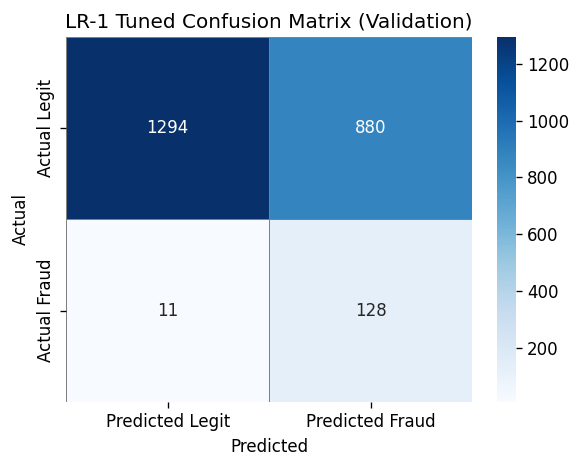

In [32]:
lr1_tuned = LogisticRegression(
    C=0.01,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

lr1_tuned.fit(X_train, y_train)

# Validation probabilities
y_val_proba_lr1_tuned = lr1_tuned.predict_proba(X_val)[:, 1]

# Default threshold = 0.5
y_val_pred_lr1_tuned = (y_val_proba_lr1_tuned >= 0.5).astype(int)

# Metrics at threshold 0.5
lr1_tuned_val_pr_auc = average_precision_score(y_val, y_val_proba_lr1_tuned)
lr1_tuned_val_roc_auc = roc_auc_score(y_val, y_val_proba_lr1_tuned)
lr1_tuned_val_precision = precision_score(y_val, y_val_pred_lr1_tuned, zero_division=0)
lr1_tuned_val_recall = recall_score(y_val, y_val_pred_lr1_tuned, zero_division=0)
lr1_tuned_val_f1 = f1_score(y_val, y_val_pred_lr1_tuned, zero_division=0)
lr1_tuned_val_cm = confusion_matrix(y_val, y_val_pred_lr1_tuned)

print("=== LR-1 Tuned Validation Results (threshold=0.5) ===")
print(f"PR-AUC:   {lr1_tuned_val_pr_auc:.4f}")
print(f"ROC-AUC:  {lr1_tuned_val_roc_auc:.4f}")
print(f"Precision:{lr1_tuned_val_precision:.4f}")
print(f"Recall:   {lr1_tuned_val_recall:.4f}")
print(f"F1-score: {lr1_tuned_val_f1:.4f}")
print("Confusion matrix:")
print(lr1_tuned_val_cm)

fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    lr1_tuned_val_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
    linewidths=0.5,
    linecolor="gray",
    ax=ax
)

ax.set_title("LR-1 Tuned Confusion Matrix (Validation)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Threshold Sweep

In [33]:
thresholds = np.arange(0.05, 0.95, 0.05)

lr_thresh_rows = []

for t in thresholds:
    preds = (y_val_proba_lr1_tuned >= t).astype(int)
    lr_thresh_rows.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall": round(recall_score(y_val, preds, zero_division=0), 3),
        "f1": round(f1_score(y_val, preds, zero_division=0), 3),
    })

lr_thresh_df = pd.DataFrame(lr_thresh_rows)

best_lr_idx = lr_thresh_df["f1"].idxmax()
best_lr_threshold = lr_thresh_df.loc[best_lr_idx, "threshold"]

print("=== LR-1 Threshold Sweep ===")
print(lr_thresh_df.to_string(index=False))
print(f"\nBest threshold: {best_lr_threshold:.2f}")

=== LR-1 Threshold Sweep ===
 threshold  precision  recall    f1
      0.05      0.062   1.000 0.118
      0.10      0.063   1.000 0.118
      0.15      0.066   1.000 0.124
      0.20      0.095   0.978 0.172
      0.25      0.119   0.971 0.212
      0.30      0.127   0.964 0.225
      0.35      0.127   0.935 0.224
      0.40      0.127   0.928 0.223
      0.45      0.127   0.928 0.223
      0.50      0.127   0.921 0.223
      0.55      0.127   0.849 0.222
      0.60      0.141   0.597 0.228
      0.65      0.149   0.496 0.229
      0.70      0.168   0.273 0.208
      0.75      0.181   0.137 0.156
      0.80      0.455   0.036 0.067
      0.85      1.000   0.007 0.014
      0.90      0.000   0.000 0.000

Best threshold: 0.65


## LR-1 Tuned — Threshold vs Metrics

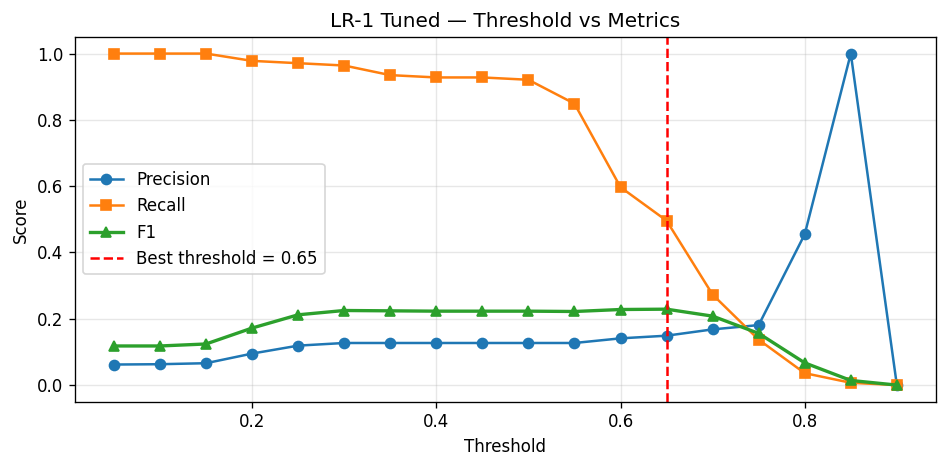

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(lr_thresh_df["threshold"], lr_thresh_df["precision"], marker="o", label="Precision")
ax.plot(lr_thresh_df["threshold"], lr_thresh_df["recall"], marker="s", label="Recall")
ax.plot(lr_thresh_df["threshold"], lr_thresh_df["f1"], marker="^", linewidth=2, label="F1")

ax.axvline(
    best_lr_threshold,
    color="red",
    linestyle="--",
    label=f"Best threshold = {best_lr_threshold:.2f}"
)

ax.set_title("LR-1 Tuned — Threshold vs Metrics")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## LR-1 Final Validation Results (tuned threshold)

=== LR-1 Final Validation Results (tuned threshold) ===
PR-AUC:    0.1779
Threshold: 0.65
Precision: 0.1490
Recall:    0.4964
F1-score:  0.2292
Confusion matrix:
[[1780  394]
 [  70   69]]


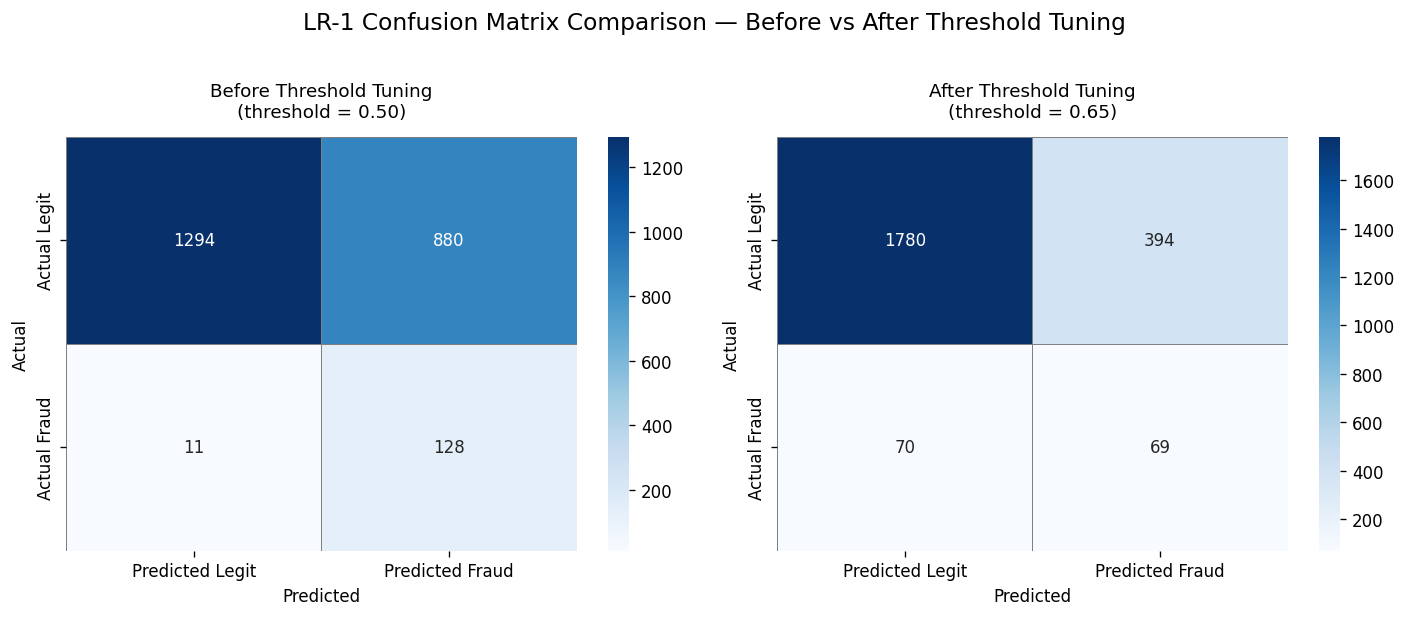

In [35]:
y_val_pred_lr1_final = (y_val_proba_lr1_tuned >= best_lr_threshold).astype(int)

lr1_final_pr_auc   = average_precision_score(y_val, y_val_proba_lr1_tuned)
lr1_final_precision = precision_score(y_val, y_val_pred_lr1_final, zero_division=0)
lr1_final_recall = recall_score(y_val, y_val_pred_lr1_final, zero_division=0)
lr1_final_f1 = f1_score(y_val, y_val_pred_lr1_final, zero_division=0)
lr1_final_cm = confusion_matrix(y_val, y_val_pred_lr1_final)

print("=== LR-1 Final Validation Results (tuned threshold) ===")
print(f"PR-AUC:    {lr1_final_pr_auc:.4f}")
print(f"Threshold: {best_lr_threshold:.2f}")
print(f"Precision: {lr1_final_precision:.4f}")
print(f"Recall:    {lr1_final_recall:.4f}")
print(f"F1-score:  {lr1_final_f1:.4f}")
print("Confusion matrix:")
print(lr1_final_cm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BEFORE threshold tuning (0.5)
sns.heatmap(
    lr1_tuned_val_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
    linewidths=0.5,
    linecolor="gray",
    ax=axes[0]
)

axes[0].set_title(
    "Before Threshold Tuning\n(threshold = 0.50)",
    fontsize=11,
    pad=12
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


# AFTER threshold tuning
sns.heatmap(
    lr1_final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
    linewidths=0.5,
    linecolor="gray",
    ax=axes[1]
)

axes[1].set_title(
    f"After Threshold Tuning\n(threshold = {best_lr_threshold:.2f})",
    fontsize=11,
    pad=12
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Main title
plt.suptitle(
    "LR-1 Confusion Matrix Comparison — Before vs After Threshold Tuning",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

# Random Forest

In [36]:
def build_rf_model(class_weight=None):
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    return model

## Fitting the 3 models

In [37]:
# RF 1: No resampling.
X_train_rf1, y_train_rf1 = no_resampling(X_train, y_train)
rf1 = build_rf_model(class_weight="balanced") # class_weight to balanced.
rf1.fit(X_train_rf1, y_train_rf1)

# RF 2: Random oversampling
X_train_rf2, y_train_rf2 = random_oversampling(X_train, y_train)
rf2 = build_rf_model(class_weight=None)
rf2.fit(X_train_rf2, y_train_rf2)

# RF 3: SMOTE
X_train_rf3, y_train_rf3 = smote_resampling(X_train, y_train)
rf3 = build_rf_model(class_weight=None)
rf3.fit(X_train_rf3, y_train_rf3)

print("All 3 Random Forest models fitted.")

All 3 Random Forest models fitted.


## Validation predictions + metrics

In [38]:
# RF 1: No resampling.
y_val_proba_rf1 = rf1.predict_proba(X_val)[:, 1]
y_val_pred_rf1 = (y_val_proba_rf1 >= 0.5).astype(int)

rf1_val_pr_auc = average_precision_score(y_val, y_val_proba_rf1)
rf1_val_roc_auc = roc_auc_score(y_val, y_val_proba_rf1)
rf1_val_precision = precision_score(y_val, y_val_pred_rf1, zero_division=0)
rf1_val_recall = recall_score(y_val, y_val_pred_rf1, zero_division=0)
rf1_val_f1 = f1_score(y_val, y_val_pred_rf1, zero_division=0)
rf1_val_cm = confusion_matrix(y_val, y_val_pred_rf1)

# RF 2: Random oversampling
y_val_proba_rf2 = rf2.predict_proba(X_val)[:, 1]
y_val_pred_rf2 = (y_val_proba_rf2 >= 0.5).astype(int)

rf2_val_pr_auc = average_precision_score(y_val, y_val_proba_rf2)
rf2_val_roc_auc = roc_auc_score(y_val, y_val_proba_rf2)
rf2_val_precision = precision_score(y_val, y_val_pred_rf2, zero_division=0)
rf2_val_recall = recall_score(y_val, y_val_pred_rf2, zero_division=0)
rf2_val_f1 = f1_score(y_val, y_val_pred_rf2, zero_division=0)
rf2_val_cm = confusion_matrix(y_val, y_val_pred_rf2)

# RF 3: SMOTE
y_val_proba_rf3 = rf3.predict_proba(X_val)[:, 1]
y_val_pred_rf3 = (y_val_proba_rf3 >= 0.5).astype(int)

rf3_val_pr_auc = average_precision_score(y_val, y_val_proba_rf3)
rf3_val_roc_auc = roc_auc_score(y_val, y_val_proba_rf3)
rf3_val_precision = precision_score(y_val, y_val_pred_rf3, zero_division=0)
rf3_val_recall = recall_score(y_val, y_val_pred_rf3, zero_division=0)
rf3_val_f1 = f1_score(y_val, y_val_pred_rf3, zero_division=0)
rf3_val_cm = confusion_matrix(y_val, y_val_pred_rf3)

## Metrics Summary comparison table

In [39]:
results_rf = pd.DataFrame({
    'Model': ['RF 1 (no resampling)', 'RF 2 (oversampling)', 'RF 3 (SMOTE)'],
    'PR-AUC': [rf1_val_pr_auc,    rf2_val_pr_auc,    rf3_val_pr_auc],
    'ROC-AUC':   [rf1_val_roc_auc,   rf2_val_roc_auc,   rf3_val_roc_auc],
    'Precision': [rf1_val_precision,  rf2_val_precision,  rf3_val_precision],
    'Recall':    [rf1_val_recall,     rf2_val_recall,     rf3_val_recall],
    'F1':        [rf1_val_f1,         rf2_val_f1,         rf3_val_f1],
}).round(4)

print("\n=== Random Forest — Validation Results ===")
print(results_rf.to_string(index=False))


=== Random Forest — Validation Results ===
               Model  PR-AUC  ROC-AUC  Precision  Recall     F1
RF 1 (no resampling)  0.2387   0.8240     0.8333  0.0360 0.0690
 RF 2 (oversampling)  0.2407   0.8247     0.6429  0.0647 0.1176
        RF 3 (SMOTE)  0.2080   0.8105     0.5000  0.0360 0.0671


## Confusion Matrix (Validation) Comparison

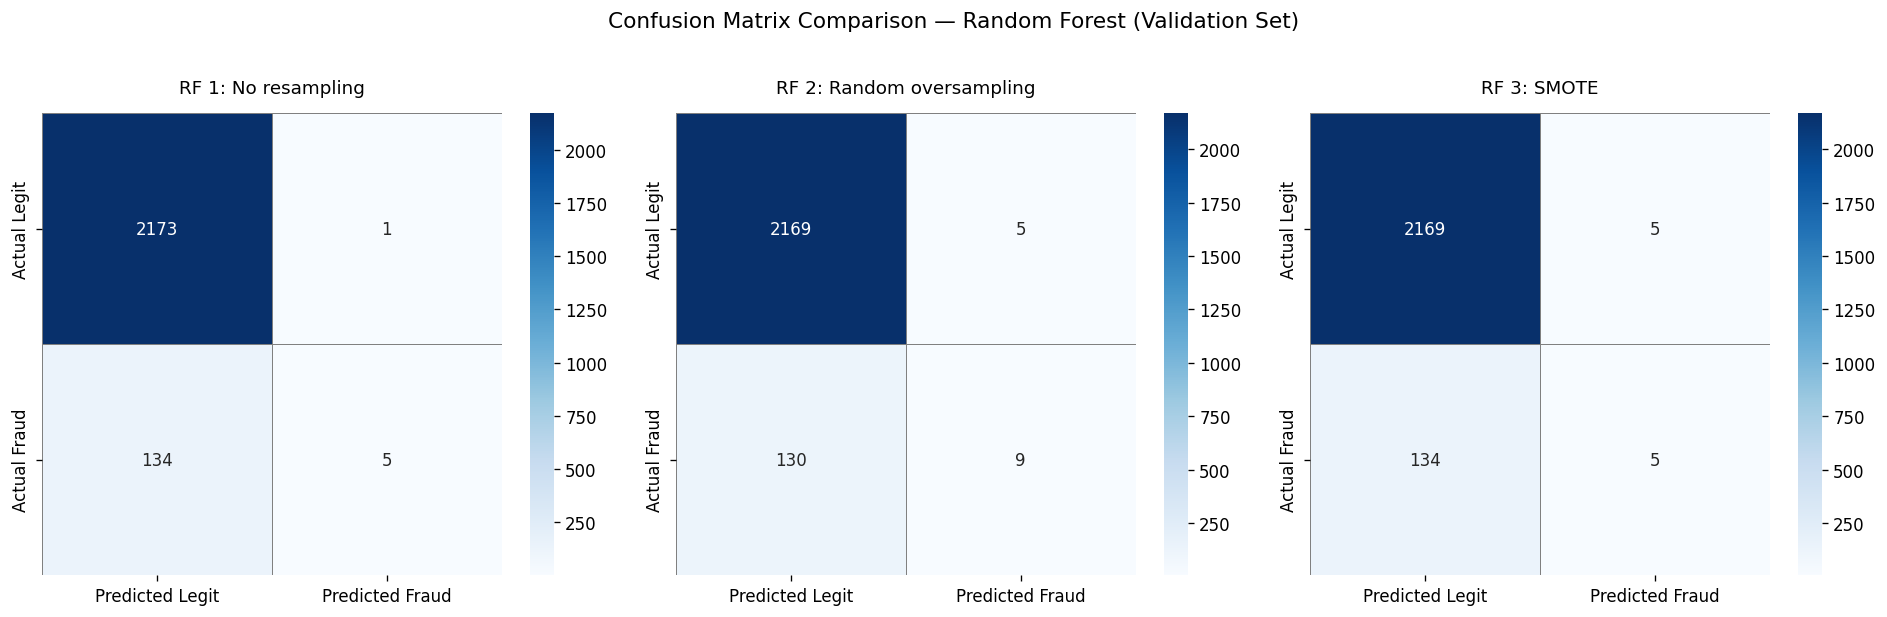

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_lr = [
    (rf1_val_cm, 'RF 1: No resampling'),
    (rf2_val_cm, 'RF 2: Random oversampling'),
    (rf3_val_cm, 'RF 3: SMOTE'),
]

for ax, (cm, title) in zip(axes, models_lr):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Random Forest (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Precision-Recall Curve Comparison

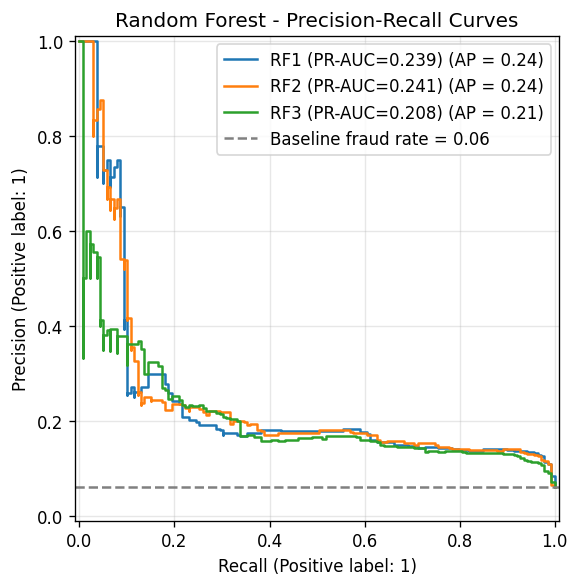

In [41]:
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf1,
    name=f"RF1 (PR-AUC={rf1_val_pr_auc:.3f})",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf2,
    name=f"RF2 (PR-AUC={rf2_val_pr_auc:.3f})",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf3,
    name=f"RF3 (PR-AUC={rf3_val_pr_auc:.3f})",
    ax=ax
)

fraud_rate = y_val.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--",
           label=f"Baseline fraud rate = {fraud_rate:.2f}")

ax.set_title("Random Forest - Precision-Recall Curves")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Random Forest Hyperparameter Tuning -- RF 1 & RF 2


In [43]:
# Parameter search space
rf_param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

base_rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=1  # changed from -1
)

# Randomized search
rf1_random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=1,  # changed from -1
    verbose=1
)

# Fit search
rf1_random_search.fit(X_train, y_train)

# Results
rf1_best_params = rf1_random_search.best_params_
rf1_best_score = rf1_random_search.best_score_

print("\n=== RF-1 Coarse Search Results ===")
print(f"Best CV PR-AUC: {rf1_best_score:.4f}")
print("Best Parameters:")
print(rf1_best_params)

rf2_random_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight=None, random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)
rf2_random_search.fit(X_train_rf2, y_train_rf2)

print("\n=== RF-2 Coarse Search Results ===")
print(f"Best CV PR-AUC: {rf2_random_search.best_score_:.4f}")
print(f"Best params: {rf2_random_search.best_params_}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits

=== RF-1 Coarse Search Results ===
Best CV PR-AUC: 0.1856
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Fitting 3 folds for each of 15 candidates, totalling 45 fits

=== RF-2 Coarse Search Results ===
Best CV PR-AUC: 1.0000
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


# Build tuned RF model


In [44]:
# RF-1 Tuned
rf1_tuned = RandomForestClassifier(
    n_estimators=rf1_random_search.best_params_["n_estimators"],
    max_depth=rf1_random_search.best_params_["max_depth"],
    min_samples_split=rf1_random_search.best_params_["min_samples_split"],
    min_samples_leaf=rf1_random_search.best_params_["min_samples_leaf"],
    max_features=rf1_random_search.best_params_["max_features"],
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf1_tuned.fit(X_train, y_train)

y_val_proba_rf1_tuned = rf1_tuned.predict_proba(X_val)[:, 1]
y_val_pred_rf1_tuned = (y_val_proba_rf1_tuned >= 0.5).astype(int)

rf1_tuned_val_prauc = average_precision_score(y_val, y_val_proba_rf1_tuned)
rf1_tuned_val_rocauc = roc_auc_score(y_val, y_val_proba_rf1_tuned)
rf1_tuned_val_precision = precision_score(y_val, y_val_pred_rf1_tuned, zero_division=0)
rf1_tuned_val_recall = recall_score(y_val, y_val_pred_rf1_tuned, zero_division=0)
rf1_tuned_val_f1 = f1_score(y_val, y_val_pred_rf1_tuned, zero_division=0)
rf1_tuned_val_cm = confusion_matrix(y_val, y_val_pred_rf1_tuned)



# RF-2 Tuned
rf2_tuned = RandomForestClassifier(
    n_estimators=rf2_random_search.best_params_["n_estimators"],
    max_depth=rf2_random_search.best_params_["max_depth"],
    min_samples_split=rf2_random_search.best_params_["min_samples_split"],
    min_samples_leaf=rf2_random_search.best_params_["min_samples_leaf"],
    max_features=rf2_random_search.best_params_["max_features"],
    class_weight=None,
    random_state=42,
    n_jobs=-1
)
rf2_tuned.fit(X_train_rf2, y_train_rf2)

y_val_proba_rf2_tuned = rf2_tuned.predict_proba(X_val)[:, 1]
y_val_pred_rf2_tuned = (y_val_proba_rf2_tuned >= 0.5).astype(int)

rf2_tuned_val_prauc = average_precision_score(y_val, y_val_proba_rf2_tuned)
rf2_tuned_val_rocauc = roc_auc_score(y_val, y_val_proba_rf2_tuned)
rf2_tuned_val_precision = precision_score(y_val, y_val_pred_rf2_tuned, zero_division=0)
rf2_tuned_val_recall = recall_score(y_val, y_val_pred_rf2_tuned, zero_division=0)
rf2_tuned_val_f1 = f1_score(y_val, y_val_pred_rf2_tuned, zero_division=0)
rf2_tuned_val_cm = confusion_matrix(y_val, y_val_pred_rf2_tuned)



## Summary metrics & confusion matrics of tuned models

=== Random Forest — Default vs Tuned (Validation) ===
         Model  PR-AUC  ROC-AUC  Precision  Recall     F1
RF-1 (default)  0.2387   0.8240     0.8333  0.0360 0.0690
    RF-1 Tuned  0.2256   0.8307     0.4375  0.1007 0.1637
RF-2 (default)  0.2407   0.8247     0.6429  0.0647 0.1176
    RF-2 Tuned  0.2306   0.8225     0.6923  0.0647 0.1184


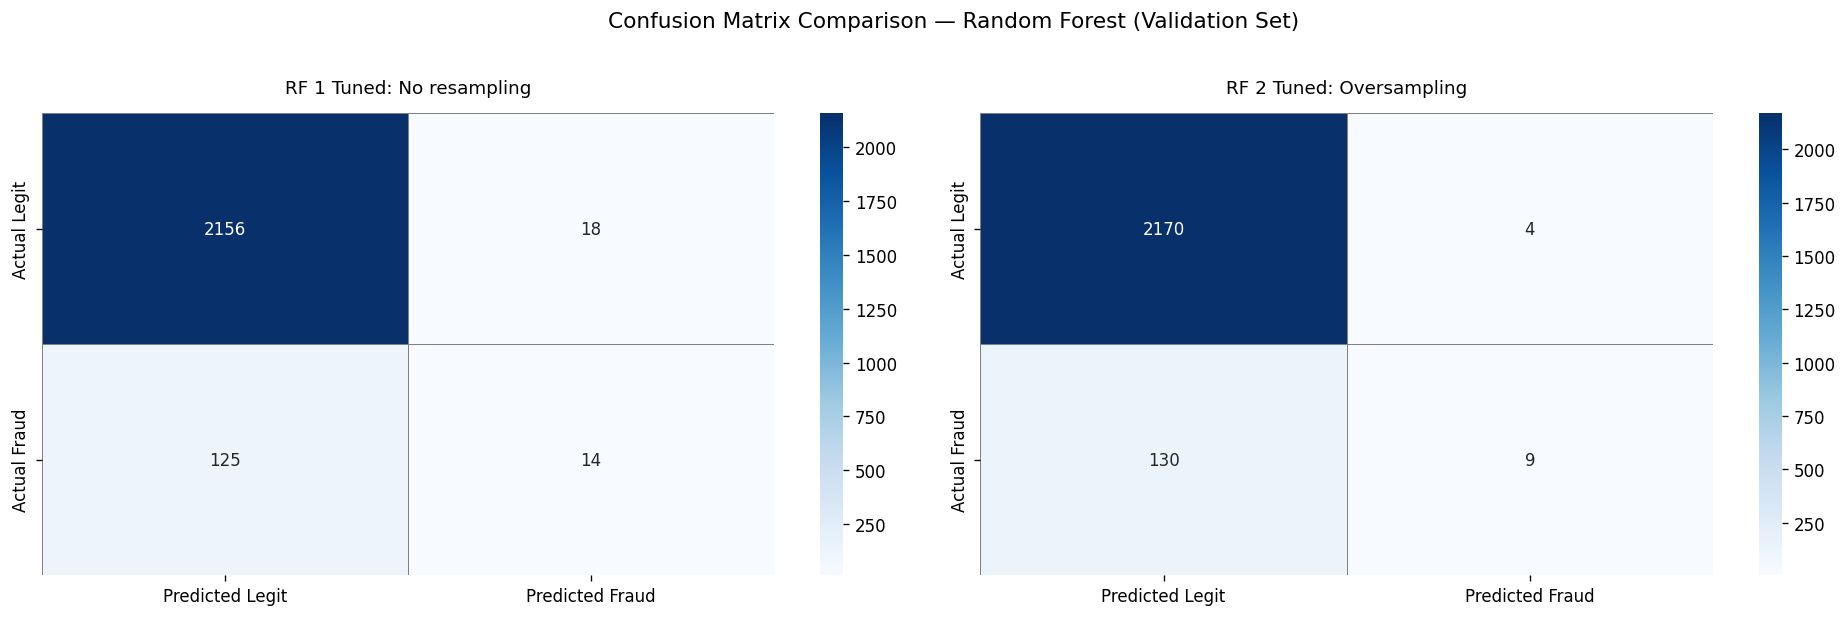

In [45]:
results_rf_tuned_vs_default = pd.DataFrame({
    'Model':     ['RF-1 (default)', 'RF-1 Tuned', 'RF-2 (default)',  'RF-2 Tuned'],
    'PR-AUC':    [rf1_val_pr_auc,        rf1_tuned_val_prauc, rf2_val_pr_auc,             rf2_tuned_val_prauc],
    'ROC-AUC':   [rf1_val_roc_auc,     rf1_tuned_val_rocauc,  rf2_val_roc_auc,           rf2_tuned_val_rocauc],
    'Precision': [rf1_val_precision,   rf1_tuned_val_precision,   rf2_val_precision,       rf2_tuned_val_precision],
    'Recall':    [rf1_val_recall,       rf1_tuned_val_recall,   rf2_val_recall,            rf2_tuned_val_recall],
    'F1':        [rf1_val_f1,          rf1_tuned_val_f1,      rf2_val_f1,                  rf2_tuned_val_f1],
}).round(4)

print("=== Random Forest — Default vs Tuned (Validation) ===")
print(results_rf_tuned_vs_default.to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

models_lr = [
    (rf1_tuned_val_cm, 'RF 1 Tuned: No resampling'),
    (rf2_tuned_val_cm, 'RF 2 Tuned: Oversampling'),
]

for ax, (cm, title) in zip(axes, models_lr):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Random Forest (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Threshold tuning

In [46]:
# ── Threshold tuning — RF-1 Tuned ────────────────────────────────────────────

thresholds = np.arange(0.05, 0.85, 0.05)

rf1_thresh_rows = []
for t in thresholds:
    preds = (y_val_proba_rf1_tuned >= t).astype(int)
    rf1_thresh_rows.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall":    round(recall_score(y_val, preds, zero_division=0), 3),
        "f1":        round(f1_score(y_val, preds, zero_division=0), 3),
    })

rf1_thresh_df = pd.DataFrame(rf1_thresh_rows)
best_rf1_idx  = rf1_thresh_df["f1"].idxmax()
best_t_rf1    = rf1_thresh_df.loc[best_rf1_idx, "threshold"]

print("=== RF-1 Tuned Threshold Sweep ===")
print(rf1_thresh_df.to_string(index=False))
print(f"\nBest threshold: {best_t_rf1:.2f}")



# ── Threshold tuning — RF-2 Tuned ────────────────────────────────────────────

rf2_thresh_rows = []
for t in thresholds:
    preds = (y_val_proba_rf2_tuned >= t).astype(int)
    rf2_thresh_rows.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall":    round(recall_score(y_val, preds, zero_division=0), 3),
        "f1":        round(f1_score(y_val, preds, zero_division=0), 3),
    })

rf2_thresh_df = pd.DataFrame(rf2_thresh_rows)
best_rf2_idx  = rf2_thresh_df["f1"].idxmax()
best_t_rf2    = rf2_thresh_df.loc[best_rf2_idx, "threshold"]

print("=== RF-2 Tuned Threshold Sweep ===")
print(rf2_thresh_df.to_string(index=False))
print(f"\nBest threshold: {best_t_rf2:.2f}")



=== RF-1 Tuned Threshold Sweep ===
 threshold  precision  recall    f1
      0.05      0.095   0.993 0.174
      0.10      0.125   0.986 0.221
      0.15      0.134   0.957 0.235
      0.20      0.139   0.820 0.238
      0.25      0.161   0.698 0.262
      0.30      0.182   0.518 0.270
      0.35      0.213   0.353 0.266
      0.40      0.206   0.187 0.196
      0.45      0.286   0.115 0.164
      0.50      0.438   0.101 0.164
      0.55      0.450   0.065 0.113
      0.60      0.615   0.058 0.105
      0.65      0.714   0.036 0.068
      0.70      0.333   0.007 0.014
      0.75      1.000   0.007 0.014
      0.80      1.000   0.007 0.014

Best threshold: 0.30
=== RF-2 Tuned Threshold Sweep ===
 threshold  precision  recall    f1
      0.05      0.119   0.986 0.212
      0.10      0.144   0.835 0.246
      0.15      0.166   0.590 0.259
      0.20      0.169   0.345 0.227
      0.25      0.232   0.237 0.235
      0.30      0.292   0.151 0.199
      0.35      0.417   0.108 0.171
      0.

## RF 1 & RF 2 Tuned — Threshold vs Metrics

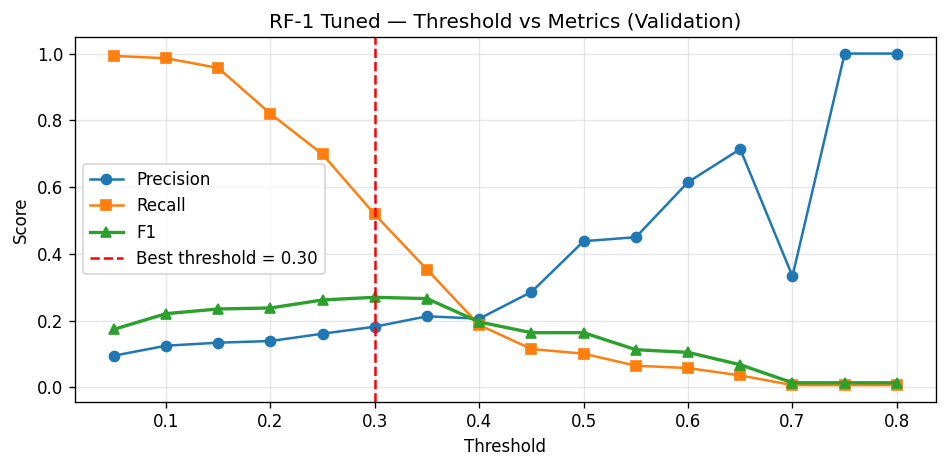

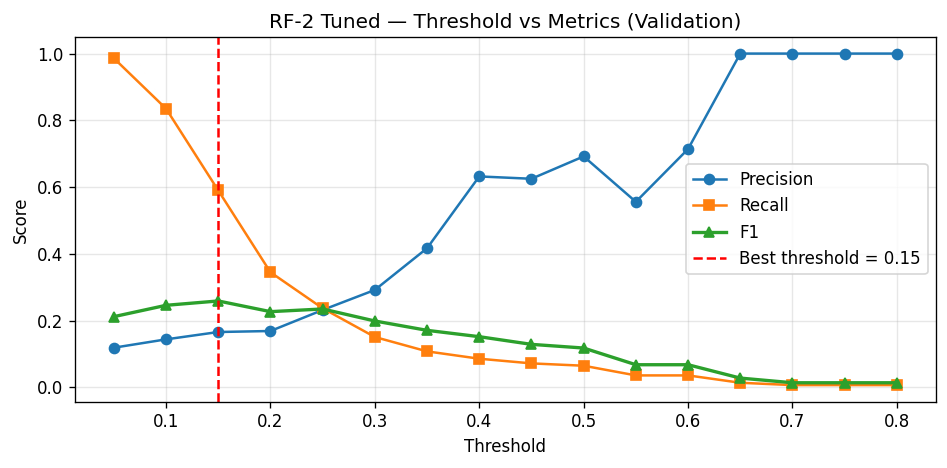

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))
(ax.plot
 (rf1_thresh_df["threshold"],
  rf1_thresh_df["precision"],
  marker="o",
  label="Precision"))

ax.plot(
    rf1_thresh_df["threshold"],
    rf1_thresh_df["recall"], marker="s", label="Recall")
ax.plot(rf1_thresh_df["threshold"], rf1_thresh_df["f1"],        marker="^", linewidth=2, label="F1")
ax.axvline(best_t_rf1, color="red", linestyle="--", label=f"Best threshold = {best_t_rf1:.2f}")
ax.set_title("RF-1 Tuned — Threshold vs Metrics (Validation)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rf2_thresh_df["threshold"], rf2_thresh_df["precision"], marker="o", label="Precision")
ax.plot(rf2_thresh_df["threshold"], rf2_thresh_df["recall"],    marker="s", label="Recall")
ax.plot(rf2_thresh_df["threshold"], rf2_thresh_df["f1"],        marker="^", linewidth=2, label="F1")
ax.axvline(best_t_rf2, color="red", linestyle="--", label=f"Best threshold = {best_t_rf2:.2f}")
ax.set_title("RF-2 Tuned — Threshold vs Metrics (Validation)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()




## recompute metrics for new threshold


In [83]:
y_val_pred_rf1_best = (y_val_proba_rf1_tuned >= best_t_rf1).astype(int)
rf1_best_prauc     = average_precision_score(y_val, y_val_proba_rf1_tuned)
rf1_best_precision = precision_score(y_val, y_val_pred_rf1_best, zero_division=0)
rf1_best_recall    = recall_score(y_val, y_val_pred_rf1_best, zero_division=0)
rf1_best_f1        = f1_score(y_val, y_val_pred_rf1_best, zero_division=0)
rf1_best_cm        = confusion_matrix(y_val, y_val_pred_rf1_best)

best_t_rf2 = 0.10
y_val_pred_rf2_best = (y_val_proba_rf2_tuned >= best_t_rf2).astype(int)
rf2_best_prauc     = average_precision_score(y_val, y_val_proba_rf2_tuned)
rf2_best_precision = precision_score(y_val, y_val_pred_rf2_best, zero_division=0)
rf2_best_recall    = recall_score(y_val, y_val_pred_rf2_best, zero_division=0)
rf2_best_f1        = f1_score(y_val, y_val_pred_rf2_best, zero_division=0)
rf2_best_cm        = confusion_matrix(y_val, y_val_pred_rf2_best)


## metrics summary table

In [84]:
results_rf_best_thresh = pd.DataFrame({
    'Model':     ['RF-1 Tuned (best thresh)', 'RF-1 Tuned (0.5)', 'RF-2 Tuned (best thresh)', 'RF-2 Tuned (0.5)'],
    'Threshold': [best_t_rf1,            0.5,               best_t_rf2,            0.5],
    'PR-AUC':    [rf1_best_prauc,         rf1_tuned_val_prauc,  rf2_best_prauc,         rf2_tuned_val_prauc],
    'Precision': [rf1_best_precision,     rf1_tuned_val_precision, rf2_best_precision,     rf2_tuned_val_precision],
    'Recall':    [rf1_best_recall,        rf1_tuned_val_recall, rf2_best_recall,        rf2_tuned_val_recall],
    'F1':        [rf1_best_f1,            rf1_tuned_val_f1,     rf2_best_f1,            rf2_tuned_val_f1],
}).round(4)

print("=== RF Tuned — Best Threshold vs Default (0.5) ===")
print(results_rf_best_thresh.to_string(index=False))

=== RF Tuned — Best Threshold vs Default (0.5) ===
                   Model  Threshold  PR-AUC  Precision  Recall     F1
RF-1 Tuned (best thresh)        0.3  0.2256     0.1823  0.5180 0.2697
        RF-1 Tuned (0.5)        0.5  0.2256     0.4375  0.1007 0.1637
RF-2 Tuned (best thresh)        0.1  0.2306     0.1439  0.8345 0.2455
        RF-2 Tuned (0.5)        0.5  0.2306     0.6923  0.0647 0.1184


## Condusion Matrix - new vs old threshold

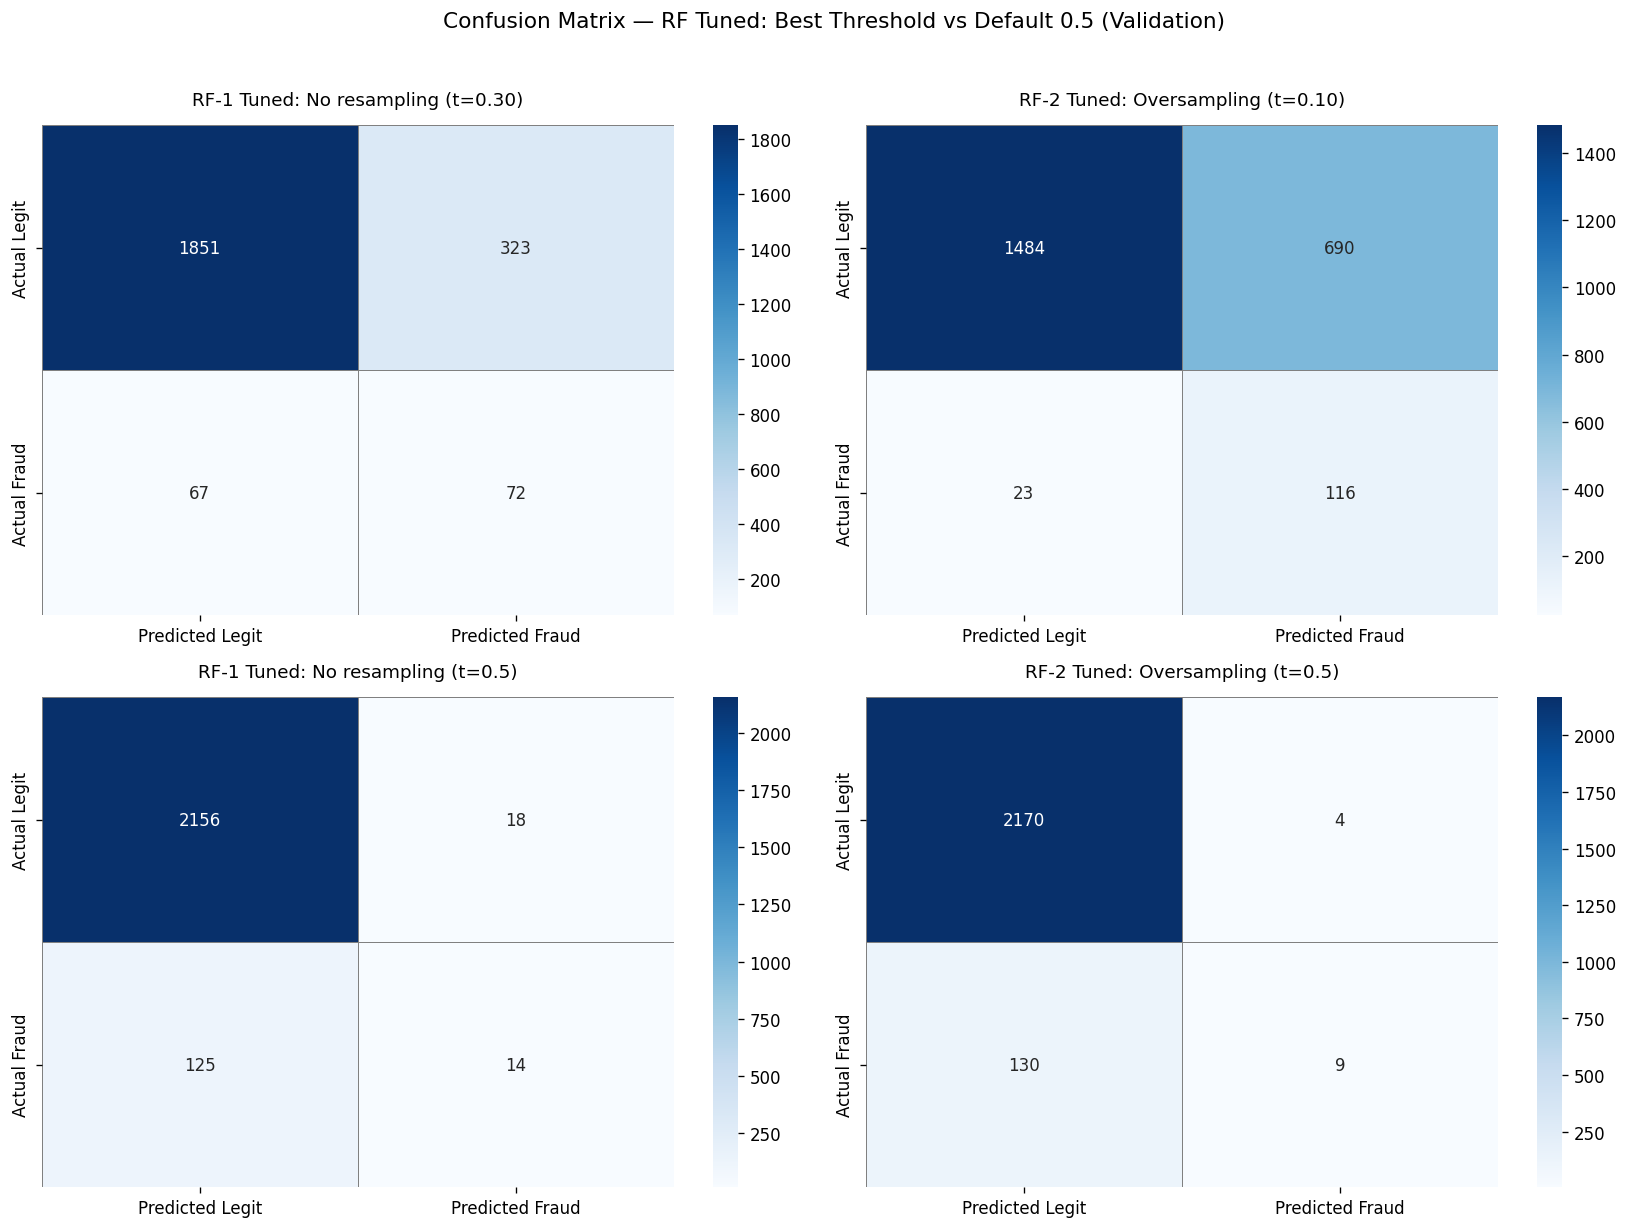

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row — best threshold
models_best = [
    (rf1_best_cm, f'RF-1 Tuned: No resampling (t={best_t_rf1:.2f})'),
    (rf2_best_cm, f'RF-2 Tuned: Oversampling (t={best_t_rf2:.2f})'),
]

for ax, (cm, title) in zip(axes[0], models_best):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

# Bottom row — default threshold 0.5
models_default = [
    (rf1_tuned_val_cm, 'RF-1 Tuned: No resampling (t=0.5)'),
    (rf2_tuned_val_cm, 'RF-2 Tuned: Oversampling (t=0.5)'),
]

for ax, (cm, title) in zip(axes[1], models_default):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix — RF Tuned: Best Threshold vs Default 0.5 (Validation)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Evaulation (threshold 0.5)

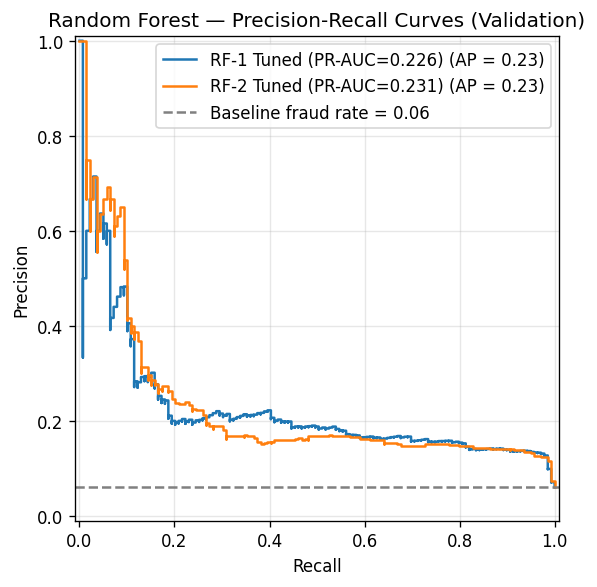

In [86]:
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf1_tuned,
    name=f"RF-1 Tuned (PR-AUC={rf1_tuned_val_prauc:.3f})",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf2_tuned,
    name=f"RF-2 Tuned (PR-AUC={rf2_tuned_val_prauc:.3f})",
    ax=ax
)

fraud_rate = y_val.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--",
           label=f"Baseline fraud rate = {fraud_rate:.2f}")

ax.set_title("Random Forest — Precision-Recall Curves (Validation)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## evaluation

In [87]:
if rf1_best_prauc >= rf2_best_prauc:
    best_rf_model   = rf1_tuned
    best_rf_thresh  = best_t_rf1
    best_rf_proba   = y_val_proba_rf1_tuned
    best_rf_prauc   = rf1_best_prauc
    winner_rf_label = "RF-1 Tuned (no resampling)"
else:
    best_rf_model   = rf2_tuned
    best_rf_thresh  = best_t_rf2
    best_rf_proba   = y_val_proba_rf2_tuned
    best_rf_prauc   = rf2_best_prauc
    winner_rf_label = "RF-2 Tuned (oversampling)"

print(f"\nWinner: {winner_rf_label}")
print(f"Threshold applied to test set: {best_rf_thresh:.2f}")


Winner: RF-2 Tuned (oversampling)
Threshold applied to test set: 0.10


#

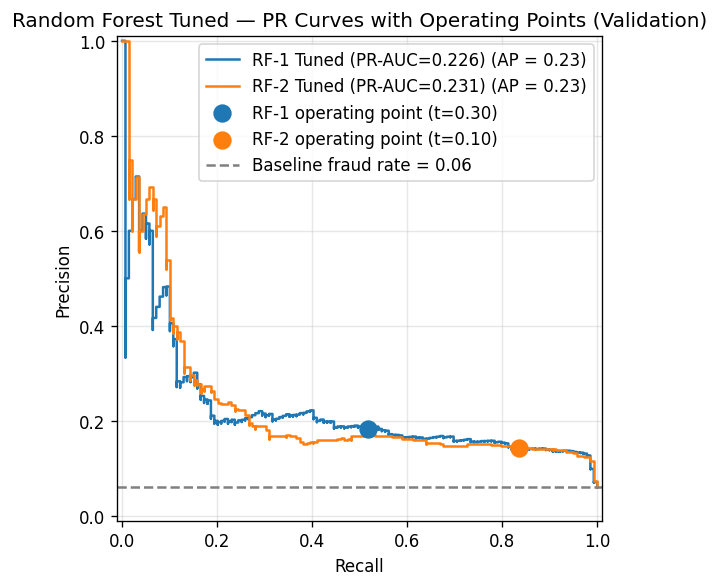

In [88]:
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf1_tuned,
    name=f"RF-1 Tuned (PR-AUC={rf1_tuned_val_prauc:.3f})",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_rf2_tuned,
    name=f"RF-2 Tuned (PR-AUC={rf2_tuned_val_prauc:.3f})",
    ax=ax
)

# Mark operating points at best threshold
for proba, thresh, label in [
    (y_val_proba_rf1_tuned, best_t_rf1, f"RF-1 operating point (t={best_t_rf1:.2f})"),
    (y_val_proba_rf2_tuned, best_t_rf2, f"RF-2 operating point (t={best_t_rf2:.2f})"),
]:
    preds = (proba >= thresh).astype(int)
    p = precision_score(y_val, preds, zero_division=0)
    r = recall_score(y_val, preds, zero_division=0)
    ax.scatter(r, p, s=100, zorder=5, label=label)

fraud_rate = y_val.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--",
           label=f"Baseline fraud rate = {fraud_rate:.2f}")

ax.set_title("Random Forest Tuned — PR Curves with Operating Points (Validation)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## feature importance

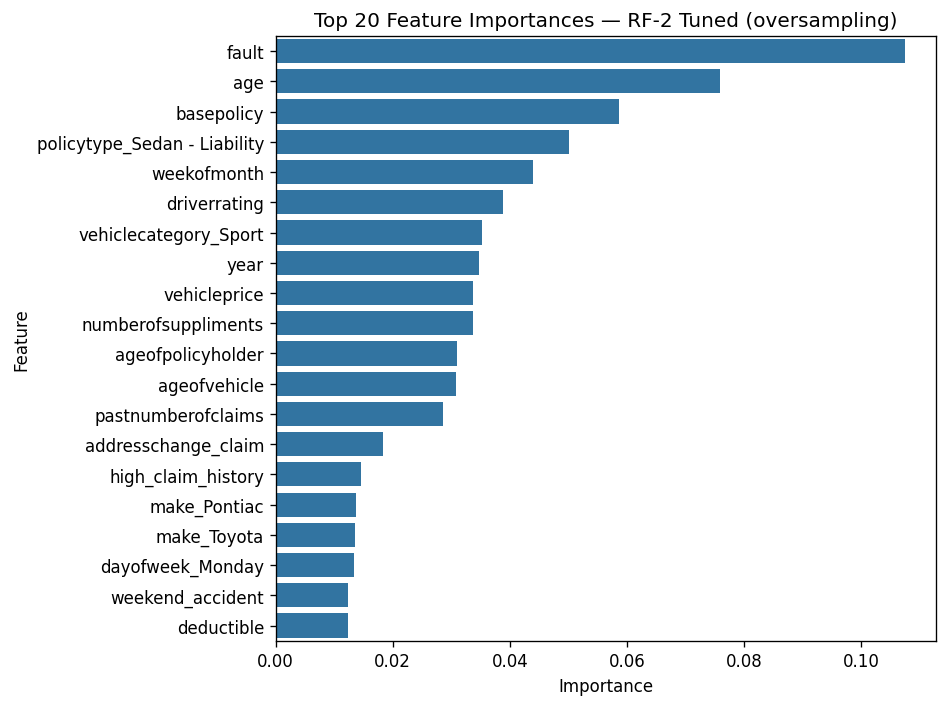

In [89]:
importances = pd.Series(
    best_rf_model.feature_importances_,
    index=X_train.columns
)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top20.values, y=top20.index, ax=ax)
ax.set_title(f"Top 20 Feature Importances — {winner_rf_label}")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

# XGBoost

In [55]:
def build_xgb_model(scale_pos_weight=1.0):
    # Core XGBoost model
    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=1
    )
    
    return model

###  XGB-1: no resampling

In [56]:
# Keep original training data
X_train_nr, y_train_nr = no_resampling(X_train, y_train)

# Compute imbalance ratio
neg = (y_train_nr == 0).sum()
pos = (y_train_nr == 1).sum()
scale_pos_weight = neg / pos

# Build model
xgb_xgb1 = build_xgb_model(scale_pos_weight=scale_pos_weight)

# Fit model
xgb_xgb1.fit(X_train_nr, y_train_nr)

# Compute validation predictions
y_val_proba_xgb1 = xgb_xgb1.predict_proba(X_val)[:, 1]
y_val_pred_xgb1 = (y_val_proba_xgb1 >= 0.5).astype(int)

# Compute validation metrics
xgb1_val_pr_auc = average_precision_score(y_val, y_val_proba_xgb1)
xgb1_val_roc_auc = roc_auc_score(y_val, y_val_proba_xgb1)
xgb1_val_precision = precision_score(y_val, y_val_pred_xgb1, zero_division=0)
xgb1_val_recall = recall_score(y_val, y_val_pred_xgb1, zero_division=0)
xgb1_val_f1 = f1_score(y_val, y_val_pred_xgb1, zero_division=0)
xgb1_val_cm = confusion_matrix(y_val, y_val_pred_xgb1)

### XGB-2: Random Oversampling

In [57]:
# Resample training data
X_train_ros, y_train_ros = random_oversampling(X_train, y_train)

# Build model
xgb_xgb2 = build_xgb_model(scale_pos_weight=1.0)

# Fit model
xgb_xgb2.fit(X_train_ros, y_train_ros)

# Compute validation predictions
y_val_proba_xgb2 = xgb_xgb2.predict_proba(X_val)[:, 1]
y_val_pred_xgb2 = (y_val_proba_xgb2 >= 0.5).astype(int)

# Compute validation metrics
xgb2_val_pr_auc = average_precision_score(y_val, y_val_proba_xgb2)
xgb2_val_roc_auc = roc_auc_score(y_val, y_val_proba_xgb2)
xgb2_val_precision = precision_score(y_val, y_val_pred_xgb2, zero_division=0)
xgb2_val_recall = recall_score(y_val, y_val_pred_xgb2, zero_division=0)
xgb2_val_f1 = f1_score(y_val, y_val_pred_xgb2, zero_division=0)
xgb2_val_cm = confusion_matrix(y_val, y_val_pred_xgb2)

### XGB-3: SMOTE


In [58]:
# XGB-3: SMOTE

# Resample training data with SMOTE
X_train_smote, y_train_smote = smote_resampling(X_train, y_train)

# Build model
xgb_xgb3 = build_xgb_model(scale_pos_weight=1.0)

# Fit model
xgb_xgb3.fit(X_train_smote, y_train_smote)

# Compute Validation predictions
y_val_proba_xgb3 = xgb_xgb3.predict_proba(X_val)[:, 1]
y_val_pred_xgb3 = (y_val_proba_xgb3 >= 0.5).astype(int)

# Compute Validation metrics
xgb3_val_pr_auc = average_precision_score(y_val, y_val_proba_xgb3)
xgb3_val_roc_auc = roc_auc_score(y_val, y_val_proba_xgb3)
xgb3_val_precision = precision_score(y_val, y_val_pred_xgb3, zero_division=0)
xgb3_val_recall = recall_score(y_val, y_val_pred_xgb3, zero_division=0)
xgb3_val_f1 = f1_score(y_val, y_val_pred_xgb3, zero_division=0)
xgb3_val_cm = confusion_matrix(y_val, y_val_pred_xgb3)

# Metrics Summary Table

In [59]:
# XGBoost - Validation results
val_results_xgb = pd.DataFrame({
    'Model':     ['XGB-1 (no resampling)', 'XGB-2 (oversampling)', 'XGB-3 (SMOTE)'],
    'PR-AUC':    [xgb1_val_pr_auc,    xgb2_val_pr_auc,    xgb3_val_pr_auc],
    'ROC-AUC':   [xgb1_val_roc_auc,   xgb2_val_roc_auc,   xgb3_val_roc_auc],
    'Precision': [xgb1_val_precision,  xgb2_val_precision,  xgb3_val_precision],
    'Recall':    [xgb1_val_recall,     xgb2_val_recall,     xgb3_val_recall],
    'F1':        [xgb1_val_f1,         xgb2_val_f1,         xgb3_val_f1],
}).round(4)

print("=== XGBoost — Validation Results ===")
print(val_results_xgb.to_string(index=False))


=== XGBoost — Validation Results ===
                Model  PR-AUC  ROC-AUC  Precision  Recall     F1
XGB-1 (no resampling)  0.2987   0.8533     0.1694  0.8058 0.2800
 XGB-2 (oversampling)  0.2909   0.8544     0.1672  0.8201 0.2777
        XGB-3 (SMOTE)  0.2676   0.8484     0.5500  0.0791 0.1384


# Confusion Matrices

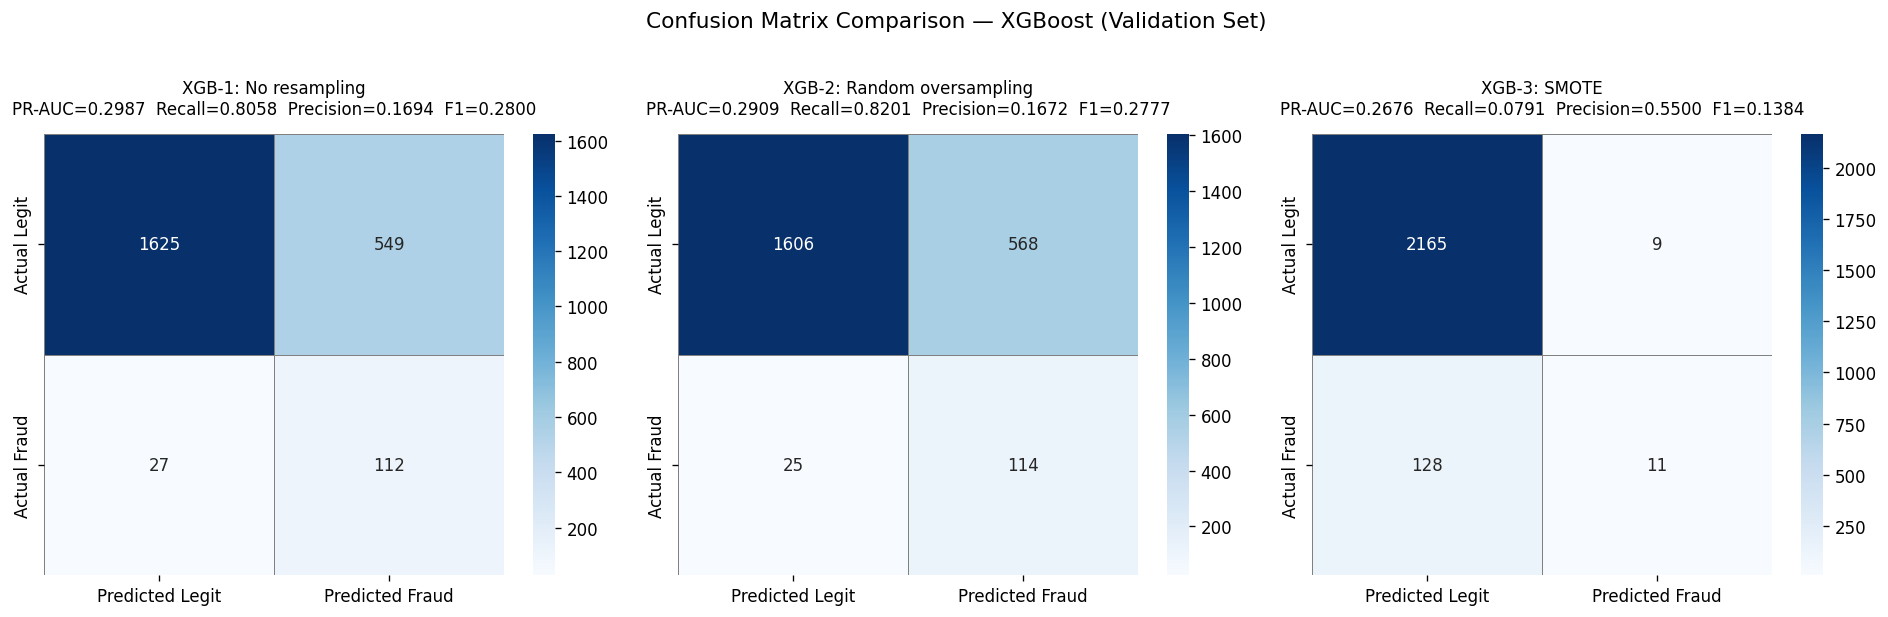

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_xgb = [
    (xgb1_val_cm, 'XGB-1: No resampling',      xgb1_val_pr_auc, xgb1_val_recall, xgb1_val_precision, xgb1_val_f1),
    (xgb2_val_cm, 'XGB-2: Random oversampling', xgb2_val_pr_auc, xgb2_val_recall, xgb2_val_precision, xgb2_val_f1),
    (xgb3_val_cm, 'XGB-3: SMOTE',               xgb3_val_pr_auc, xgb3_val_recall, xgb3_val_precision, xgb3_val_f1),
]

for ax, (cm, title, pr_auc, recall, precision, f1) in zip(axes, models_xgb):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(
        f"{title}\nPR-AUC={pr_auc:.4f}  Recall={recall:.4f}  Precision={precision:.4f}  F1={f1:.4f}",
        fontsize=10, pad=12
    )

plt.suptitle('Confusion Matrix Comparison — XGBoost (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## XGBoost Hyperparameter Tuning — Coarse-to-Fine Search
 
Following the course methodology (Lecture 12), we apply a **coarse-to-fine** strategy:
 
1. **Coarse stage** — `RandomizedSearchCV` with 15 random combinations across a broad
   parameter space, evaluated via 3-fold stratified cross-validation on the training set.
   This identifies the region of high potential in parameter space.
 
2. **Fine stage** — A targeted manual grid search over the three most impactful parameters
   (`n_estimators`, `max_depth`, `learning_rate`) around the coarse best values, with
   all other parameters fixed at coarse best.
 
3. **Threshold tuning** — The default threshold of 0.5 is arbitrary. We sweep thresholds
   on the **validation set only** to find the best balance of precision and recall.
 
4. **Test evaluation** — The test set is touched **once**, using the best model and
   best threshold chosen on validation.
 
Key constraint: validation and test sets are never used during training or tuning.
Scoring metric: `average_precision` (= PR-AUC), consistent with our main evaluation metric.
"""

In [61]:
### CELL 2 — Imports for tuning ###
matplotlib.rcParams["figure.dpi"] = 120
set_config(display='text')
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
 

"""
### Stage 1: Coarse Random Search — XGB-1 (no resampling)
 
We sample 15 random combinations from a broad distribution.
Scoring is `average_precision` (PR-AUC) via 3-fold CV on training data.
"""

In [62]:
import numpy as np
 
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Class imbalance ratio: {scale_pos_weight:.1f}x  (used as scale_pos_weight)")
 
coarse_param_dist = {
    "n_estimators":     [200, 400],
    "learning_rate":    [0.03, 0.05, 0.08],
    "max_depth":        [3, 4, 5],
    "subsample":        [0.7, 0.9],
    "colsample_bytree": [0.7, 1.0],
    "reg_lambda":       [0.5, 2.0],
    "min_child_weight": [1, 5],
}
 
base_xgb1 = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
 
coarse_search_xgb1 = RandomizedSearchCV(
    base_xgb1,
    coarse_param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=0,
)
coarse_search_xgb1.fit(X_train, y_train)
 
coarse_best_xgb1 = coarse_search_xgb1.best_params_
print(f"\nCoarse best CV PR-AUC: {coarse_search_xgb1.best_score_:.4f}")
print(f"Coarse best params:    {coarse_best_xgb1}")

Class imbalance ratio: 15.7x  (used as scale_pos_weight)

Coarse best CV PR-AUC: 0.2337
Coarse best params:    {'subsample': 0.9, 'reg_lambda': 0.5, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


"""
### Stage 2: Fine Manual Grid — XGB-1
 
We fix the coarse best values for `subsample`, `colsample_bytree`, `reg_lambda`,
and `min_child_weight`, then do a fine grid over the three highest-impact parameters:
`n_estimators`, `max_depth`, and `learning_rate`.
 
This is the "coarse-to-fine" approach from Lecture 12: random search to find the
region, grid search to exploit it precisely.
"""

In [63]:
fine_results_xgb1 = []

for n_est in [350, 400, 500]:
    for depth in [4, 5, 6]:
        for lr in [0.02, 0.03, 0.05]:
            m = xgb.XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",
                n_estimators=n_est,
                learning_rate=lr,
                max_depth=depth,
                subsample=0.9,
                colsample_bytree=1.0,
                reg_lambda=0.5,
                min_child_weight=1,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=1,
                tree_method="hist",
            )
            m.fit(X_train, y_train)
            p = m.predict_proba(X_val)[:, 1]
            score = average_precision_score(y_val, p)
            fine_results_xgb1.append({
                "n_estimators": n_est,
                "max_depth": depth,
                "learning_rate": lr,
                "val_pr_auc": round(score, 4),
            })

fine_df_xgb1 = pd.DataFrame(fine_results_xgb1).sort_values("val_pr_auc", ascending=False)
print("Fine grid results (top 10):")
print(fine_df_xgb1.head(10).to_string(index=False))

best_fine_xgb1 = fine_df_xgb1.iloc[0]
print(f"\nBest fine params: n_estimators={int(best_fine_xgb1['n_estimators'])}, "
      f"max_depth={int(best_fine_xgb1['max_depth'])}, learning_rate={best_fine_xgb1['learning_rate']}")
print(f"Val PR-AUC: {best_fine_xgb1['val_pr_auc']:.4f}")

Fine grid results (top 10):
 n_estimators  max_depth  learning_rate  val_pr_auc
          350          5           0.05      0.2892
          400          4           0.05      0.2881
          400          5           0.05      0.2856
          500          5           0.05      0.2850
          350          4           0.05      0.2850
          500          4           0.03      0.2837
          400          5           0.03      0.2828
          500          4           0.05      0.2822
          500          5           0.03      0.2813
          500          5           0.02      0.2797

Best fine params: n_estimators=350, max_depth=5, learning_rate=0.05
Val PR-AUC: 0.2892


In [81]:
xgb1_tuned = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=int(best_fine_xgb1["n_estimators"]),
    learning_rate=best_fine_xgb1["learning_rate"],
    max_depth=int(best_fine_xgb1["max_depth"]),
    subsample=0.9,
    colsample_bytree=1.0,
    reg_lambda=0.5,
    min_child_weight=1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=1,
    tree_method="hist",
)
xgb1_tuned.fit(X_train, y_train)
y_val_proba_xgb1_tuned = xgb1_tuned.predict_proba(X_val)[:, 1]
y_val_pred_xgb1_tuned    = (y_val_proba_xgb1_tuned >= 0.5).astype(int)

xgb1_tuned_val_prauc  = average_precision_score(y_val, y_val_proba_xgb1_tuned)
xgb1_tuned_val_rocauc = roc_auc_score(y_val, y_val_proba_xgb1_tuned)

xgb1_tuned_val_precision = precision_score(y_val, y_val_pred_xgb1_tuned, zero_division=0)
xgb1_tuned_val_recall    = recall_score(y_val, y_val_pred_xgb1_tuned, zero_division=0)
xgb1_tuned_val_f1        = f1_score(y_val, y_val_pred_xgb1_tuned, zero_division=0)

print(f"XGB-1 Tuned | Val PR-AUC: {xgb1_tuned_val_prauc:.4f}  Val ROC-AUC: {xgb1_tuned_val_rocauc:.4f}")
print(f"             Precision:   {xgb1_tuned_val_precision:.4f}  Recall: {xgb1_tuned_val_recall:.4f}  F1: {xgb1_tuned_val_f1:.4f}")



XGB-1 Tuned | Val PR-AUC: 0.2892  Val ROC-AUC: 0.8604
             Precision:   0.2129  Recall: 0.6906  F1: 0.3254


"""
### Stage 3: Threshold Tuning — XGB-1
 
The default threshold of 0.5 is arbitrary (Lecture 12). We sweep thresholds from 0.10
to 0.80 on the **validation set** and pick the one that maximises F1. This balances
the business cost of missing fraud (false negatives) against annoying legitimate
customers (false positives).
 
Important: the threshold is selected on validation data. The test set is not touched here.
"""

XGB-1 Threshold sweep (validation):
 threshold  precision  recall    f1
      0.10      0.125   0.964 0.221
      0.15      0.137   0.950 0.240
      0.20      0.146   0.921 0.252
      0.25      0.155   0.899 0.265
      0.30      0.164   0.863 0.275
      0.35      0.175   0.842 0.290
      0.40      0.185   0.806 0.301
      0.45      0.196   0.755 0.312
      0.50      0.213   0.691 0.325
      0.55      0.228   0.597 0.330
      0.60      0.227   0.489 0.310
      0.65      0.222   0.360 0.275
      0.70      0.240   0.259 0.249
      0.75      0.281   0.194 0.230
      0.80      0.328   0.137 0.193

=> Best threshold: 0.55  F1=0.330  Precision=0.228  Recall=0.597


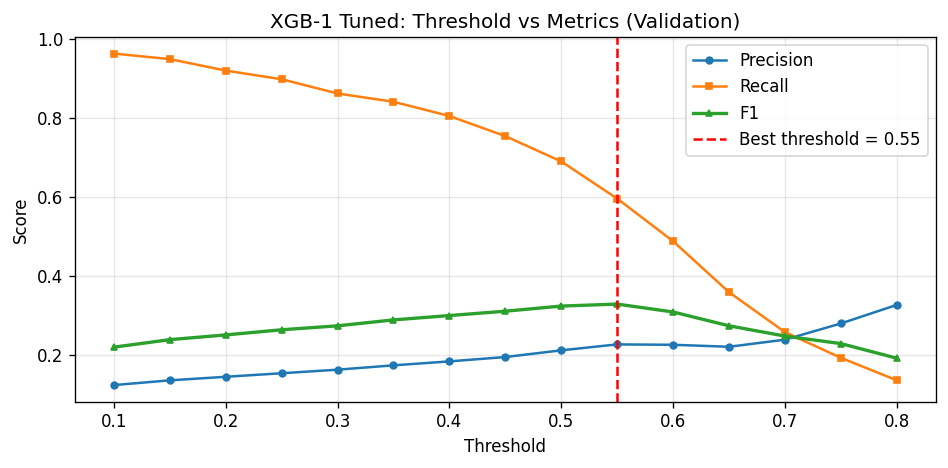

In [65]:
thresholds = np.arange(0.10, 0.85, 0.05)
thresh_rows_xgb1 = []
 
for t in thresholds:
    preds = (y_val_proba_xgb1_tuned >= t).astype(int)
    thresh_rows_xgb1.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall":    round(recall_score(y_val, preds, zero_division=0), 3),
        "f1":        round(f1_score(y_val, preds, zero_division=0), 3),
    })
 
thresh_df_xgb1 = pd.DataFrame(thresh_rows_xgb1)
best_idx_xgb1  = thresh_df_xgb1["f1"].idxmax()
best_t_xgb1    = thresh_df_xgb1.loc[best_idx_xgb1, "threshold"]
print("XGB-1 Threshold sweep (validation):")
print(thresh_df_xgb1.to_string(index=False))
print(f"\n=> Best threshold: {best_t_xgb1:.2f}  "
      f"F1={thresh_df_xgb1.loc[best_idx_xgb1,'f1']:.3f}  "
      f"Precision={thresh_df_xgb1.loc[best_idx_xgb1,'precision']:.3f}  "
      f"Recall={thresh_df_xgb1.loc[best_idx_xgb1,'recall']:.3f}")
 
# Plot threshold vs precision/recall/F1
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_df_xgb1["threshold"], thresh_df_xgb1["precision"], label="Precision", marker="o", ms=4)
ax.plot(thresh_df_xgb1["threshold"], thresh_df_xgb1["recall"],    label="Recall",    marker="s", ms=4)
ax.plot(thresh_df_xgb1["threshold"], thresh_df_xgb1["f1"],        label="F1",        marker="^", ms=4, lw=2)
ax.axvline(best_t_xgb1, color="red", linestyle="--", label=f"Best threshold = {best_t_xgb1:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_title("XGB-1 Tuned: Threshold vs Metrics (Validation)")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
 

"""
### Coarse-to-Fine Tuning — XGB-2 (Random Oversampling)
 
We repeat the same two-stage process for XGB-2.
"""


In [66]:
X_train_ros, y_train_ros = random_oversampling(X_train, y_train)
 
coarse_search_xgb2 = RandomizedSearchCV(
    xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="aucpr",
        scale_pos_weight=1.0, random_state=42, n_jobs=-1, tree_method="hist",
    ),
    coarse_param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=0,
)
coarse_search_xgb2.fit(X_train_ros, y_train_ros)
coarse_best_xgb2 = coarse_search_xgb2.best_params_
print(f"XGB-2 Coarse best CV PR-AUC: {coarse_search_xgb2.best_score_:.4f}")
print(f"XGB-2 Coarse best params:    {coarse_best_xgb2}")
 
# Fine grid XGB-2
fine_results_xgb2 = []
for n_est in [350, 400, 500]:
    for depth in [4, 5, 6]:
        for lr in [0.02, 0.03, 0.05]:
            m = xgb.XGBClassifier(
                objective="binary:logistic", eval_metric="aucpr",
                n_estimators=n_est, learning_rate=lr, max_depth=depth,
                subsample=0.9, colsample_bytree=1.0, reg_lambda=0.5,
                min_child_weight=1, scale_pos_weight=1.0,
                random_state=42, n_jobs=-1, tree_method="hist",
            )
            m.fit(X_train_ros, y_train_ros)
            p = m.predict_proba(X_val)[:, 1]
            score = average_precision_score(y_val, p)
            fine_results_xgb2.append({"n_estimators": n_est, "max_depth": depth,
                                       "learning_rate": lr, "val_pr_auc": round(score, 4)})
 
fine_df_xgb2 = pd.DataFrame(fine_results_xgb2).sort_values("val_pr_auc", ascending=False)
print("\nXGB-2 Fine grid results (top 10):")
print(fine_df_xgb2.head(10).to_string(index=False))

best_fine_xgb2 = fine_df_xgb2.iloc[0]
print(f"\nBest fine params: n_estimators={int(best_fine_xgb2['n_estimators'])}, "
      f"max_depth={int(best_fine_xgb2['max_depth'])}, learning_rate={best_fine_xgb2['learning_rate']}")
print(f"Val PR-AUC: {best_fine_xgb2['val_pr_auc']:.4f}")

XGB-2 Coarse best CV PR-AUC: 0.9789
XGB-2 Coarse best params:    {'subsample': 0.9, 'reg_lambda': 2.0, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.08, 'colsample_bytree': 1.0}

XGB-2 Fine grid results (top 10):
 n_estimators  max_depth  learning_rate  val_pr_auc
          400          5           0.03      0.2923
          400          6           0.03      0.2920
          500          5           0.03      0.2914
          350          6           0.03      0.2911
          350          5           0.03      0.2910
          350          5           0.05      0.2900
          400          4           0.03      0.2883
          500          5           0.02      0.2878
          400          5           0.05      0.2874
          400          5           0.02      0.2873

Best fine params: n_estimators=400, max_depth=5, learning_rate=0.03
Val PR-AUC: 0.2923


In [82]:
best_fine_xgb2 = fine_df_xgb2.iloc[0]

xgb2_tuned = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=int(best_fine_xgb2["n_estimators"]),
    learning_rate=best_fine_xgb2["learning_rate"],
    max_depth=int(best_fine_xgb2["max_depth"]),
    subsample=0.9,
    colsample_bytree=1.0,
    reg_lambda=0.5,
    min_child_weight=1,
    scale_pos_weight=1.0,
    random_state=42,
    n_jobs=1,
    tree_method="hist",
)
xgb2_tuned.fit(X_train_ros, y_train_ros)
y_val_proba_xgb2_tuned = xgb2_tuned.predict_proba(X_val)[:, 1]
y_val_pred_xgb2_tuned    = (y_val_proba_xgb2_tuned >= 0.5).astype(int)

xgb2_tuned_val_precision = precision_score(y_val, y_val_pred_xgb2_tuned, zero_division=0)
xgb2_tuned_val_recall    = recall_score(y_val, y_val_pred_xgb2_tuned, zero_division=0)
xgb2_tuned_val_f1        = f1_score(y_val, y_val_pred_xgb2_tuned, zero_division=0)
xgb2_tuned_val_prauc  = average_precision_score(y_val, y_val_proba_xgb2_tuned)
xgb2_tuned_val_rocauc = roc_auc_score(y_val, y_val_proba_xgb2_tuned)

print(f"XGB-2 Tuned | Val PR-AUC: {xgb2_tuned_val_prauc:.4f}  Val ROC-AUC: {xgb2_tuned_val_rocauc:.4f}")
print(f"             Precision:   {xgb2_tuned_val_precision:.4f}  Recall: {xgb2_tuned_val_recall:.4f}  F1: {xgb2_tuned_val_f1:.4f}")




XGB-2 Tuned | Val PR-AUC: 0.2923  Val ROC-AUC: 0.8603
             Precision:   0.1808  Recall: 0.7986  F1: 0.2948


XGB-2 Threshold sweep (validation):
 threshold  precision  recall    f1
      0.10      0.112   0.971 0.201
      0.15      0.123   0.950 0.217
      0.20      0.130   0.935 0.229
      0.25      0.138   0.928 0.241
      0.30      0.145   0.914 0.250
      0.35      0.151   0.906 0.260
      0.40      0.163   0.899 0.275
      0.45      0.175   0.871 0.292
      0.50      0.181   0.799 0.295
      0.55      0.196   0.734 0.309
      0.60      0.210   0.640 0.316
      0.65      0.228   0.511 0.315
      0.70      0.252   0.374 0.301
      0.75      0.270   0.245 0.257
      0.80      0.338   0.158 0.216

=> Best threshold: 0.60  F1=0.316  Precision=0.210  Recall=0.640


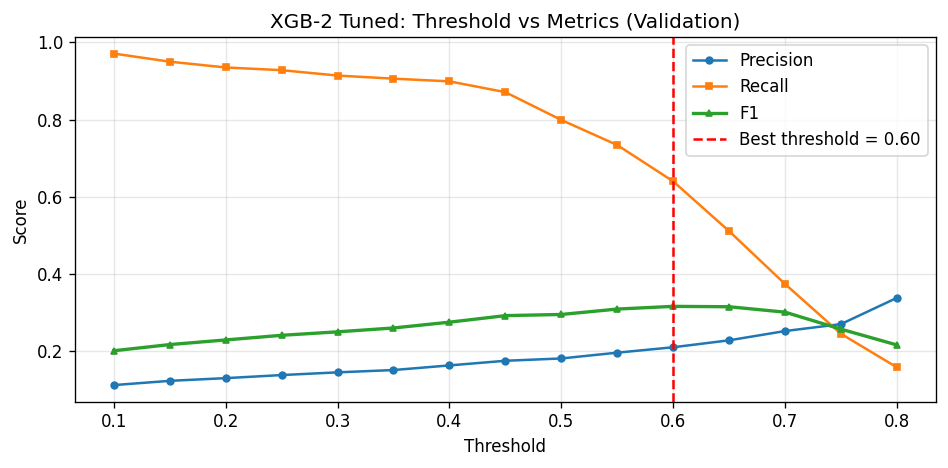

In [68]:
thresh_rows_xgb2 = []
for t in thresholds:
    preds = (y_val_proba_xgb2_tuned >= t).astype(int)
    thresh_rows_xgb2.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall":    round(recall_score(y_val, preds, zero_division=0), 3),
        "f1":        round(f1_score(y_val, preds, zero_division=0), 3),
    })

thresh_df_xgb2 = pd.DataFrame(thresh_rows_xgb2)
best_idx_xgb2  = thresh_df_xgb2["f1"].idxmax()
best_t_xgb2    = thresh_df_xgb2.loc[best_idx_xgb2, "threshold"]
print("XGB-2 Threshold sweep (validation):")
print(thresh_df_xgb2.to_string(index=False))
print(f"\n=> Best threshold: {best_t_xgb2:.2f}  "
      f"F1={thresh_df_xgb2.loc[best_idx_xgb2,'f1']:.3f}  "
      f"Precision={thresh_df_xgb2.loc[best_idx_xgb2,'precision']:.3f}  "
      f"Recall={thresh_df_xgb2.loc[best_idx_xgb2,'recall']:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_df_xgb2["threshold"], thresh_df_xgb2["precision"], label="Precision", marker="o", ms=4)
ax.plot(thresh_df_xgb2["threshold"], thresh_df_xgb2["recall"],    label="Recall",    marker="s", ms=4)
ax.plot(thresh_df_xgb2["threshold"], thresh_df_xgb2["f1"],        label="F1",        marker="^", ms=4, lw=2)
ax.axvline(best_t_xgb2, color="red", linestyle="--", label=f"Best threshold = {best_t_xgb2:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_title("XGB-2 Tuned: Threshold vs Metrics (Validation)")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


### Model Selection & Precision-Recall Curves

We compare XGB-1 and XGB-2 (tuned) by validation PR-AUC — our primary metric.
The winner is then evaluated **once** on the test set.


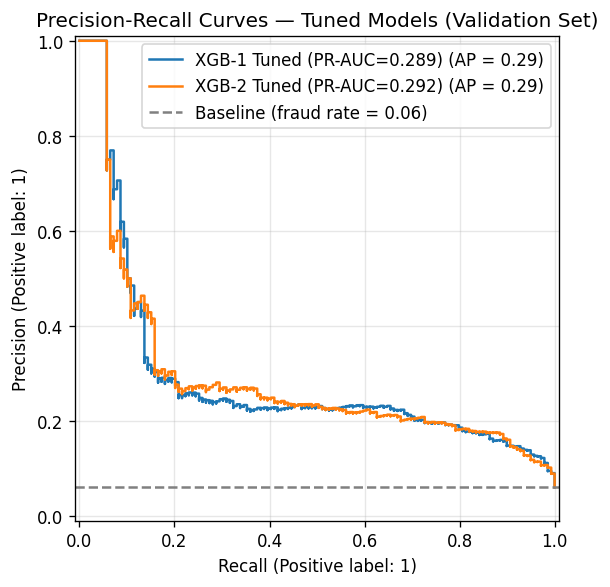

XGB-1 Tuned Val PR-AUC: 0.2892
XGB-2 Tuned Val PR-AUC: 0.2923

Winner: XGB-2 Tuned (random oversampling)
Threshold applied to test set: 0.60


In [69]:
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_xgb1_tuned,
    name=f"XGB-1 Tuned (PR-AUC={xgb1_tuned_val_prauc:.3f})", ax=ax
)
PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_xgb2_tuned,
    name=f"XGB-2 Tuned (PR-AUC={xgb2_tuned_val_prauc:.3f})", ax=ax
)
fraud_rate = y_val.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--", label=f"Baseline (fraud rate = {fraud_rate:.2f})")
ax.set_title("Precision-Recall Curves — Tuned Models (Validation Set)")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Select winner by val PR-AUC
if xgb1_tuned_val_prauc >= xgb2_tuned_val_prauc:
    best_model_tuned  = xgb1_tuned
    best_thresh_tuned = best_t_xgb1
    winner_label      = "XGB-1 Tuned (no resampling)"
else:
    best_model_tuned  = xgb2_tuned
    best_thresh_tuned = best_t_xgb2
    winner_label      = "XGB-2 Tuned (random oversampling)"

print(f"XGB-1 Tuned Val PR-AUC: {xgb1_tuned_val_prauc:.4f}")
print(f"XGB-2 Tuned Val PR-AUC: {xgb2_tuned_val_prauc:.4f}")
print(f"\nWinner: {winner_label}")
print(f"Threshold applied to test set: {best_thresh_tuned:.2f}")

## Final evaulation (validation set)

=== Final Model Comparison — Validation ===
     Model  Threshold  PR-AUC  Precision  Recall     F1
 LR Winner       0.65  0.1779     0.1490  0.4964 0.2292
 RF Winner       0.10  0.2306     0.1439  0.8345 0.2455
XGB Winner       0.60  0.2923     0.2099  0.6403 0.3162


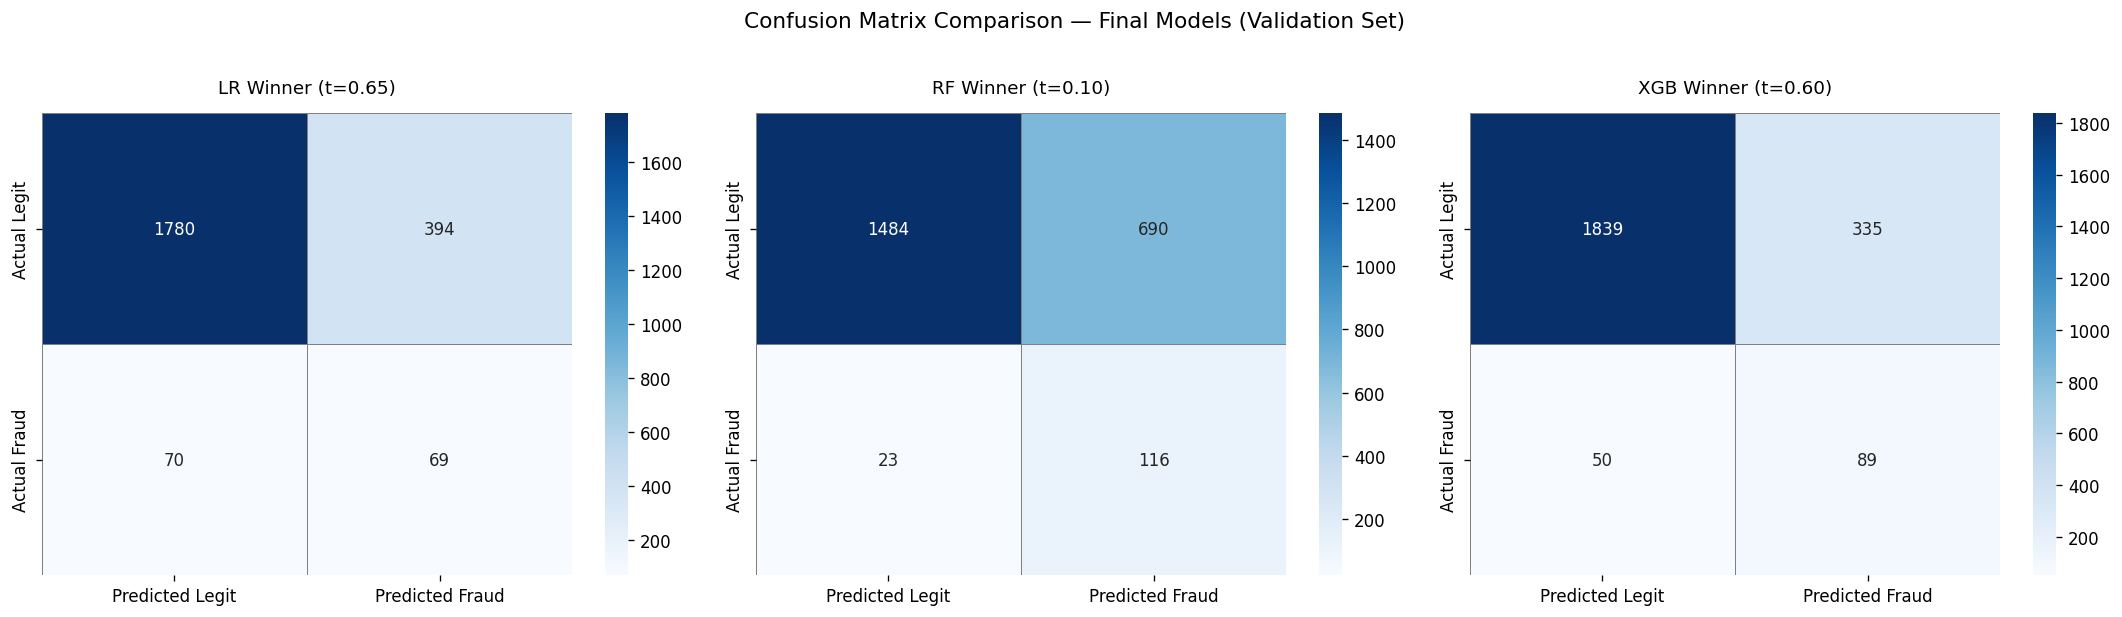

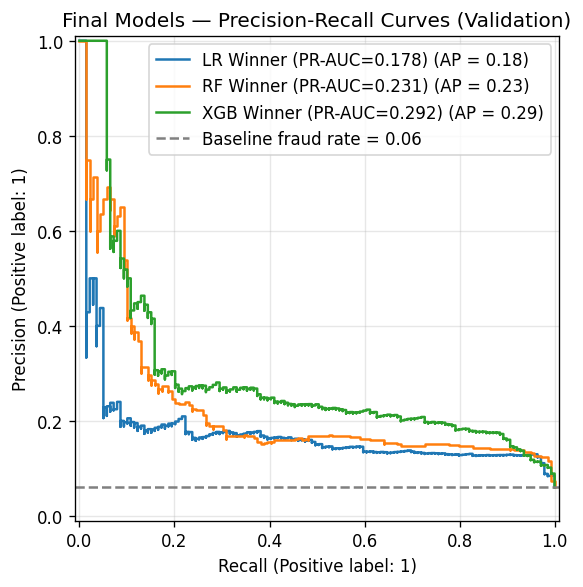

fraudfound
0    2174
1     139
Name: count, dtype: int64


In [95]:
# Recompute XGB winner val predictions using the actual winner
y_val_proba_xgb_winner = best_model_tuned.predict_proba(X_val)[:, 1]
y_val_pred_xgb_winner  = (y_val_proba_xgb_winner >= best_thresh_tuned).astype(int)

xgb_val_precision_final = precision_score(y_val, y_val_pred_xgb_winner, zero_division=0)
xgb_val_recall_final    = recall_score(y_val, y_val_pred_xgb_winner, zero_division=0)
xgb_val_f1_final        = f1_score(y_val, y_val_pred_xgb_winner, zero_division=0)
xgb_val_prauc_final     = average_precision_score(y_val, y_val_proba_xgb_winner)

results_final_val = pd.DataFrame({
    'Model':     ['LR Winner',          'RF Winner',       'XGB Winner'],
    'Threshold': [best_lr_threshold,    best_rf_thresh,    best_thresh_tuned],
    'PR-AUC':    [lr1_final_pr_auc,     rf2_best_prauc,    xgb_val_prauc_final],
    'Precision': [lr1_final_precision,  rf2_best_precision, xgb_val_precision_final],
    'Recall':    [lr1_final_recall,     rf2_best_recall,    xgb_val_recall_final],
    'F1':        [lr1_final_f1,         rf2_best_f1,        xgb_val_f1_final],
}).round(4)

print("=== Final Model Comparison — Validation ===")
print(results_final_val.to_string(index=False))

# Confusion matrices
xgb_val_cm_final = confusion_matrix(y_val, y_val_pred_xgb_winner)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_final_val = [
    (lr1_final_cm,     f'LR Winner (t={best_lr_threshold:.2f})'),
    (rf2_best_cm,      f'RF Winner (t={best_rf_thresh:.2f})'),
    (xgb_val_cm_final, f'XGB Winner (t={best_thresh_tuned:.2f})'),
]

for ax, (cm, title) in zip(axes, models_final_val):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Final Models (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# PR curves
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(y_val, y_val_proba_lr1_tuned,
    name=f"LR Winner (PR-AUC={lr1_final_pr_auc:.3f})", ax=ax)
PrecisionRecallDisplay.from_predictions(y_val, best_rf_proba,
    name=f"RF Winner (PR-AUC={best_rf_prauc:.3f})", ax=ax)
PrecisionRecallDisplay.from_predictions(y_val, y_val_proba_xgb_winner,
    name=f"XGB Winner (PR-AUC={xgb_val_prauc_final:.3f})", ax=ax)

fraud_rate = y_val.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--",
           label=f"Baseline fraud rate = {fraud_rate:.2f}")
ax.set_title("Final Models — Precision-Recall Curves (Validation)")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(y_val.value_counts())

## Test set comparison

In [92]:
# ── Test set predictions for each winner ──────────────────────────────────────

# LR winner
y_test_proba_lr  = lr1_tuned.predict_proba(X_test)[:, 1]
y_test_pred_lr   = (y_test_proba_lr >= best_lr_threshold).astype(int)

# RF winner
y_test_proba_rf  = best_rf_model.predict_proba(X_test)[:, 1]
y_test_pred_rf   = (y_test_proba_rf >= best_rf_thresh).astype(int)

# XGB winner
y_test_proba_xgb = best_model_tuned.predict_proba(X_test)[:, 1]
y_test_pred_xgb  = (y_test_proba_xgb >= best_thresh_tuned).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────────────

lr_test_prauc     = average_precision_score(y_test, y_test_proba_lr)
lr_test_rocauc    = roc_auc_score(y_test, y_test_proba_lr)
lr_test_precision = precision_score(y_test, y_test_pred_lr, zero_division=0)
lr_test_recall    = recall_score(y_test, y_test_pred_lr, zero_division=0)
lr_test_f1        = f1_score(y_test, y_test_pred_lr, zero_division=0)

rf_test_prauc     = average_precision_score(y_test, y_test_proba_rf)
rf_test_rocauc    = roc_auc_score(y_test, y_test_proba_rf)
rf_test_precision = precision_score(y_test, y_test_pred_rf, zero_division=0)
rf_test_recall    = recall_score(y_test, y_test_pred_rf, zero_division=0)
rf_test_f1        = f1_score(y_test, y_test_pred_rf, zero_division=0)

xgb_test_prauc     = average_precision_score(y_test, y_test_proba_xgb)
xgb_test_rocauc    = roc_auc_score(y_test, y_test_proba_xgb)
xgb_test_precision = precision_score(y_test, y_test_pred_xgb, zero_division=0)
xgb_test_recall    = recall_score(y_test, y_test_pred_xgb, zero_division=0)
xgb_test_f1        = f1_score(y_test, y_test_pred_xgb, zero_division=0)


results_final_test = pd.DataFrame({
    'Model':     ['LR Winner',       'RF Winner',       'XGB Winner'],
    'Threshold': [best_lr_threshold,  best_rf_thresh,    best_thresh_tuned],
    'PR-AUC':    [lr_test_prauc,      rf_test_prauc,     xgb_test_prauc],
    'ROC-AUC':   [lr_test_rocauc,     rf_test_rocauc,    xgb_test_rocauc],
    'Precision': [lr_test_precision,  rf_test_precision, xgb_test_precision],
    'Recall':    [lr_test_recall,     rf_test_recall,    xgb_test_recall],
    'F1':        [lr_test_f1,         rf_test_f1,        xgb_test_f1],
}).round(4)

print("=== Final Model Comparison — Test Set ===")
print(results_final_test.to_string(index=False))


=== Final Model Comparison — Test Set ===
     Model  Threshold  PR-AUC  ROC-AUC  Precision  Recall     F1
 LR Winner       0.65  0.1503   0.7987     0.1574  0.5362 0.2434
 RF Winner       0.10  0.2100   0.8212     0.1325  0.8188 0.2281
XGB Winner       0.60  0.2461   0.8653     0.2211  0.6377 0.3284


## Confusion matrices

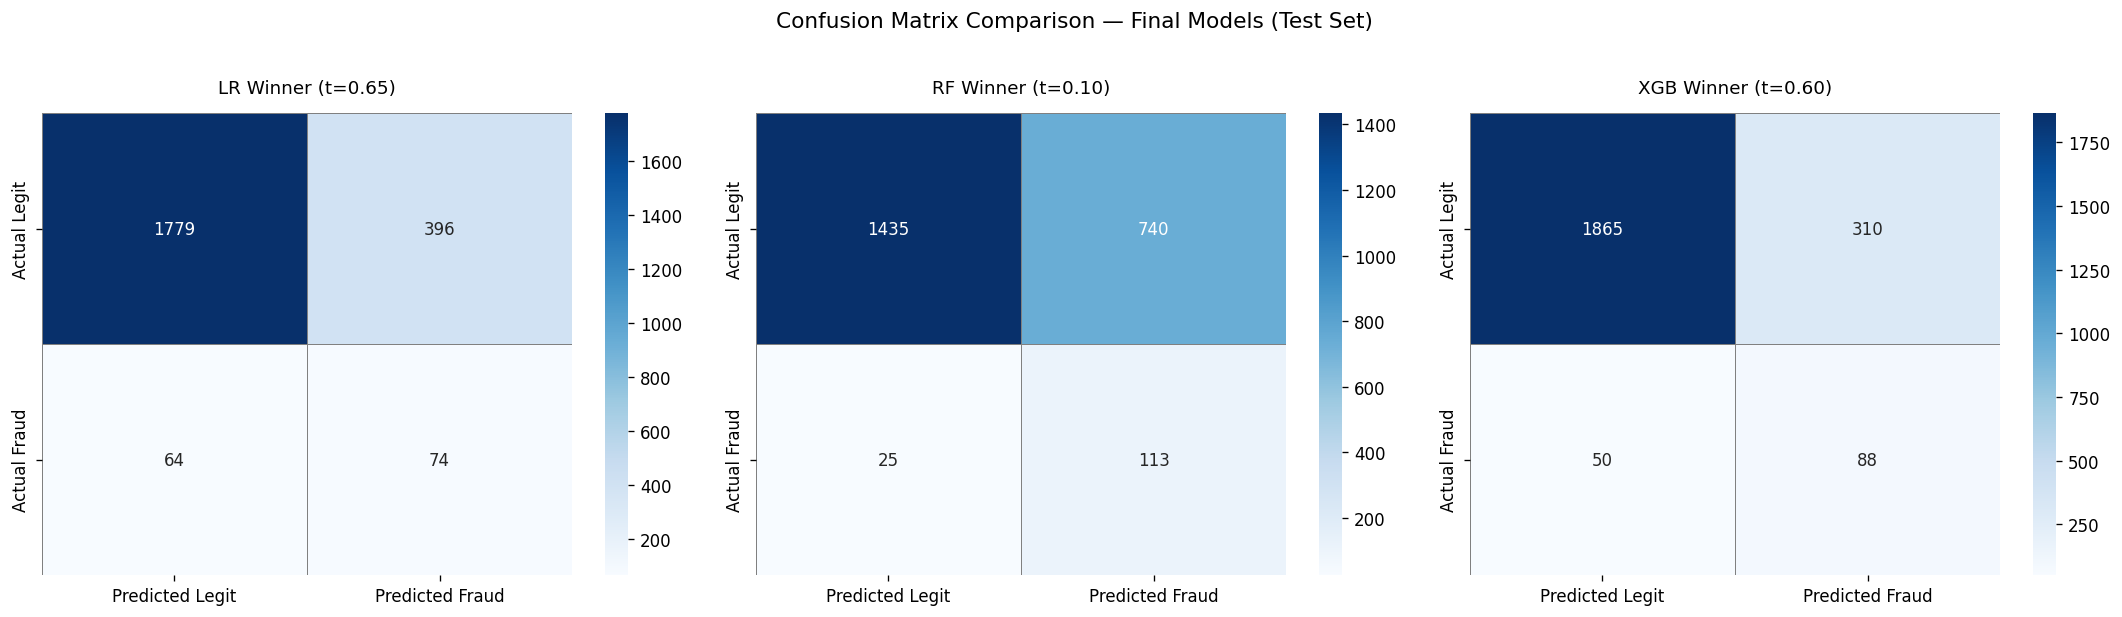

fraudfound
0    2175
1     138
Name: count, dtype: int64


In [94]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_final_test = [
    (confusion_matrix(y_test, y_test_pred_lr),  f'LR Winner (t={best_lr_threshold:.2f})'),
    (confusion_matrix(y_test, y_test_pred_rf),  f'RF Winner (t={best_rf_thresh:.2f})'),
    (confusion_matrix(y_test, y_test_pred_xgb), f'XGB Winner (t={best_thresh_tuned:.2f})'),
]

for ax, (cm, title) in zip(axes, models_final_test):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Final Models (Test Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(y_test.value_counts())

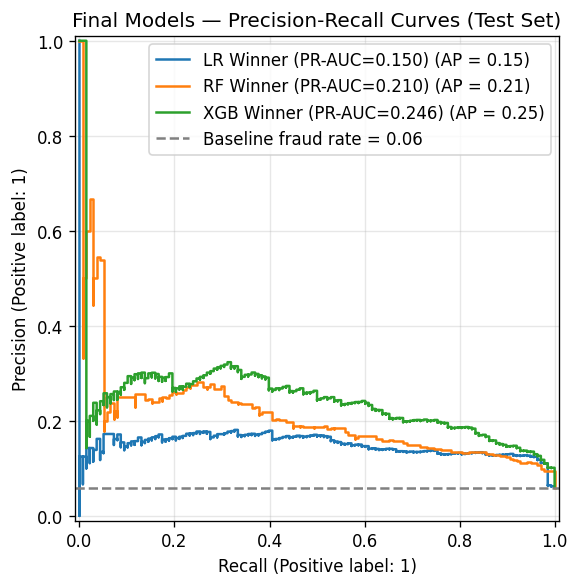

In [79]:
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_lr,
    name=f"LR Winner (PR-AUC={lr_test_prauc:.3f})", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_rf,
    name=f"RF Winner (PR-AUC={rf_test_prauc:.3f})", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba_xgb,
    name=f"XGB Winner (PR-AUC={xgb_test_prauc:.3f})", ax=ax)

fraud_rate = y_test.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--",
           label=f"Baseline fraud rate = {fraud_rate:.2f}")
ax.set_title("Final Models — Precision-Recall Curves (Test Set)")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
